# Energy champions — feature importance (train-only, clean split)

Champions from `selection_table.csv` — purged inner k-fold + 1SE, global cut **2021-10-06**.
All importance analysis uses **train data only** (post-split). The held-out 30% is **sealed**.

| Instrument | Group | Champion | AUC | Lower CI | Signal |
|------------|-------|----------|-----|----------|--------|
| cl1s | cl1s | XGB | 0.675±0.139 | 0.54 | YES |
| ho1s | energy_all | Logistic | 0.800±0.303 | 0.50 | NO |
| rb1s | energy_all | Logistic | 0.551±0.094 | 0.46 | NO |
| ng1s | energy_all | RF | 0.477±0.259 | 0.22 | NO |

> **ho1s, rb1s, ng1s** carry no confirmed signal. ho1s/rb1s/ng1s run on the pooled `energy_all`
> group; importance is scored on each instrument's own CPCV test slice. ho1s shows very high
> AUC variance (±0.303) driven by a few folds — treat point estimates with caution.
> ng1s had only ~28 train events at the global cut so 3 of 15 CPCV folds were skipped.


In [1]:
from pathlib import Path
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
from IPython.display import Image, display

BASE = Path('outputs/importance')

def show(path, width=1100):
    p = Path(path)
    if p.exists():
        display(Image(str(p), width=width))
    else:
        print(f'[missing] {p}')

def load(path):
    p = Path(path)
    if p.exists():
        return pd.read_csv(p)
    print(f'[missing] {p}')
    return pd.DataFrame()

def cluster_summary(inst):
    mem = load(BASE / inst / 'cluster_membership.csv')
    mda = load(BASE / inst / 'clustered_mda_full.csv')
    if mem.empty or mda.empty:
        return pd.DataFrame()
    grp = (
        mem.groupby('cluster')
        .agg(
            n_members=('feature', 'count'),
            dominant_pfx=('f_prefix', lambda x: x.value_counts().index[0]),
            purity=('f_prefix', lambda x: round(x.value_counts().iloc[0] / len(x), 2)),
        )
        .reset_index()
    )
    mda_sub = mda[['cluster', 'mean_drop', 'std_drop', 'significant']].copy()
    return grp.merge(mda_sub, on='cluster', how='left').sort_values('mean_drop', ascending=False)

print('Setup complete. Artifact root:', BASE.resolve())



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/opt/anaconda3/lib/python3.12/runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/opt/anaconda3/lib/python3.12/runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/opt/anaconda3/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/anaconda3/lib/python3.12/sit

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.




A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/opt/anaconda3/lib/python3.12/runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/opt/anaconda3/lib/python3.12/runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/opt/anaconda3/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/anaconda3/lib/python3.12/sit

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



Setup complete. Artifact root: /Users/harrybrowne/Downloads/Imperial Work/SystematicTrading/stml/src/stml/new_work/outputs/importance


---
## CL1S — champion: `cl1s` / XGB

**CPCV:** 15 paths · AUC 0.697 ± 0.139 · **SIGNAL** (lower CI 0.54)

**Significant clusters:** C14\_f11 only (MDA 0.224 ± 0.115) — dominates all others by ~50×.

> CL1S is dominated by a single cluster of cross-asset macro/volatility features. Within C14_f11,
> `f11_move_z` (MOVE bond volatility index z-score, SHAP 0.219) and `f2_vol_60` (60-day realised
> volatility, SHAP 0.195) are near-equally important, loading on opposite signs of PC1 —
> a single volatility-regime latent factor explains 67% of the cluster's variance.
> Notably, **F5_signal is slightly negative** (−0.004 MDA) for CL1S, meaning internal
> signal-quality features are uninformative or even detrimental — crude oil predictability
> comes entirely from external market stress signals, not signal metadata.
> MDI–SHAP agreement is strong (τ=0.71) but MDA disagrees with both (τ≈0.33/0.28),
> reflecting the sharp concentration: one cluster dominates MDA; MDI/SHAP spread across more.


### Step 1 · Feature clusters


,cluster,n_members,dominant_pfx,purity,mean_drop,std_drop,significant
4,C14_f11,5,f11_,60%,0.2238,0.1150,True
5,C15_f2,8,f2_,62%,0.0047,0.0138,False
14,C9_f1,3,f1_,33%,0.0030,0.0070,False
3,C13_f2,5,f2_,40%,0.0023,0.0078,False
0,C10_f11,7,f11_,71%,0.0021,0.0064,False
9,C4_f1,11,f1_,45%,0.0018,0.0112,False
10,C5_f11,7,f11_,57%,0.0013,0.0134,False
8,C3_f11,9,f11_,78%,0.0010,0.0119,False
7,C2_f11_lowfreq_macro,2,f11_,100%,0.0004,0.0008,False
17,F8_calendar,4,f8_,100%,0.0002,0.0007,False


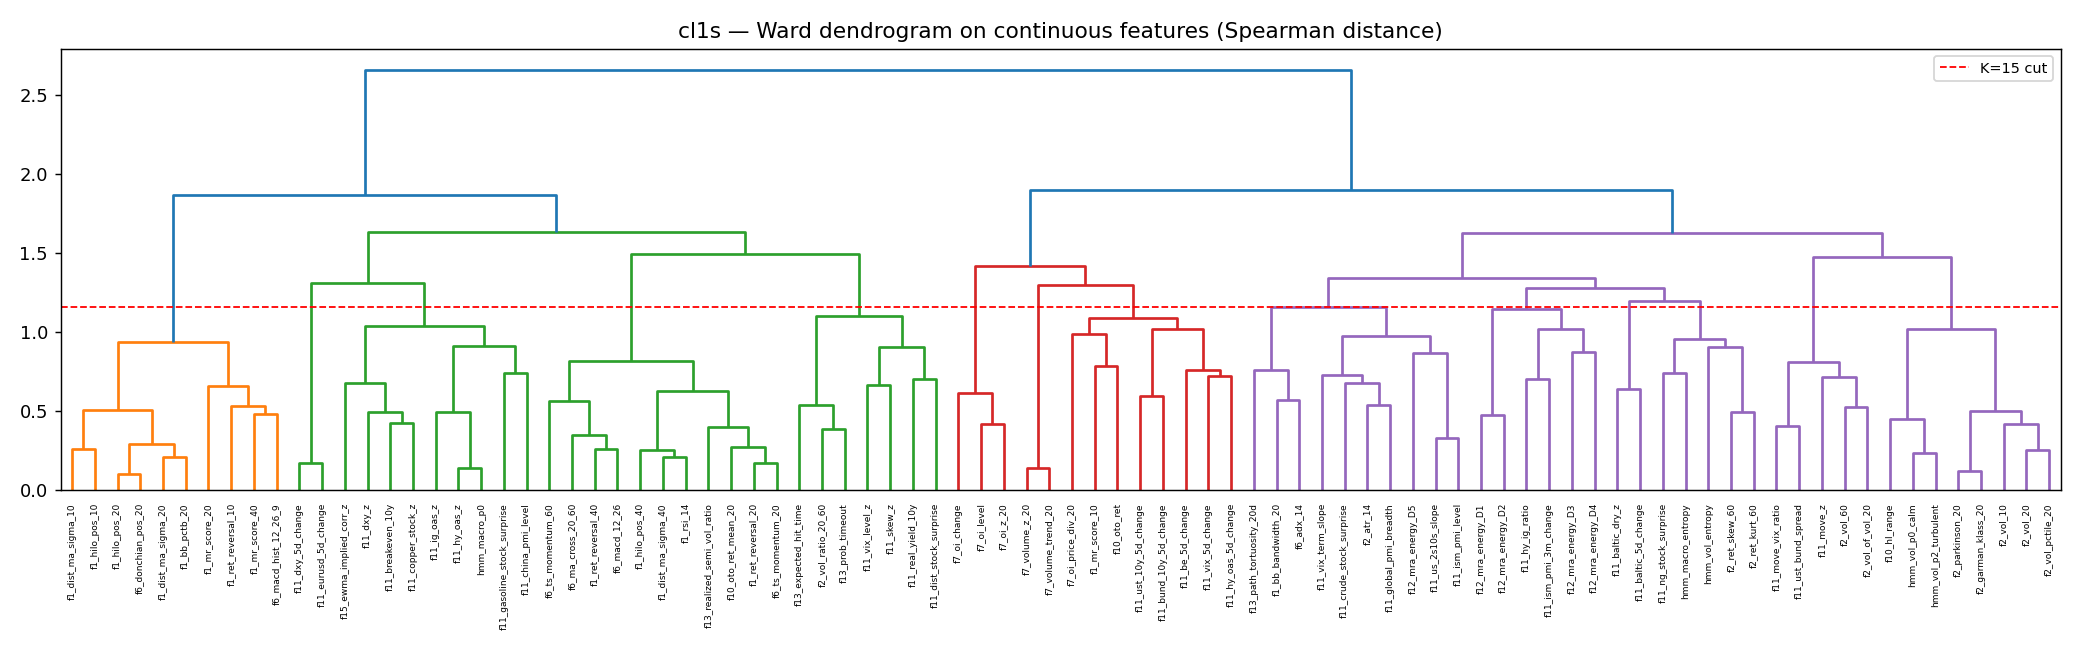

In [2]:
cs = cluster_summary('cl1s')
display(
    cs.style
    .format({'mean_drop': '{:.4f}', 'std_drop': '{:.4f}', 'purity': '{:.0%}'})
    .background_gradient(subset=['mean_drop'], cmap='RdYlGn', vmin=-0.05, vmax=0.25)
    .set_caption('cl1s — cluster summary (K=15 corr + 3 hand-assigned = 18 groups)')
)
show(BASE / 'cl1s' / 'dendrogram.png', width=1100)


### Step 2 · Cluster-level importance

Clustered MDA (dark = significant > 1σ). Cross-check with MDI and SHAP.


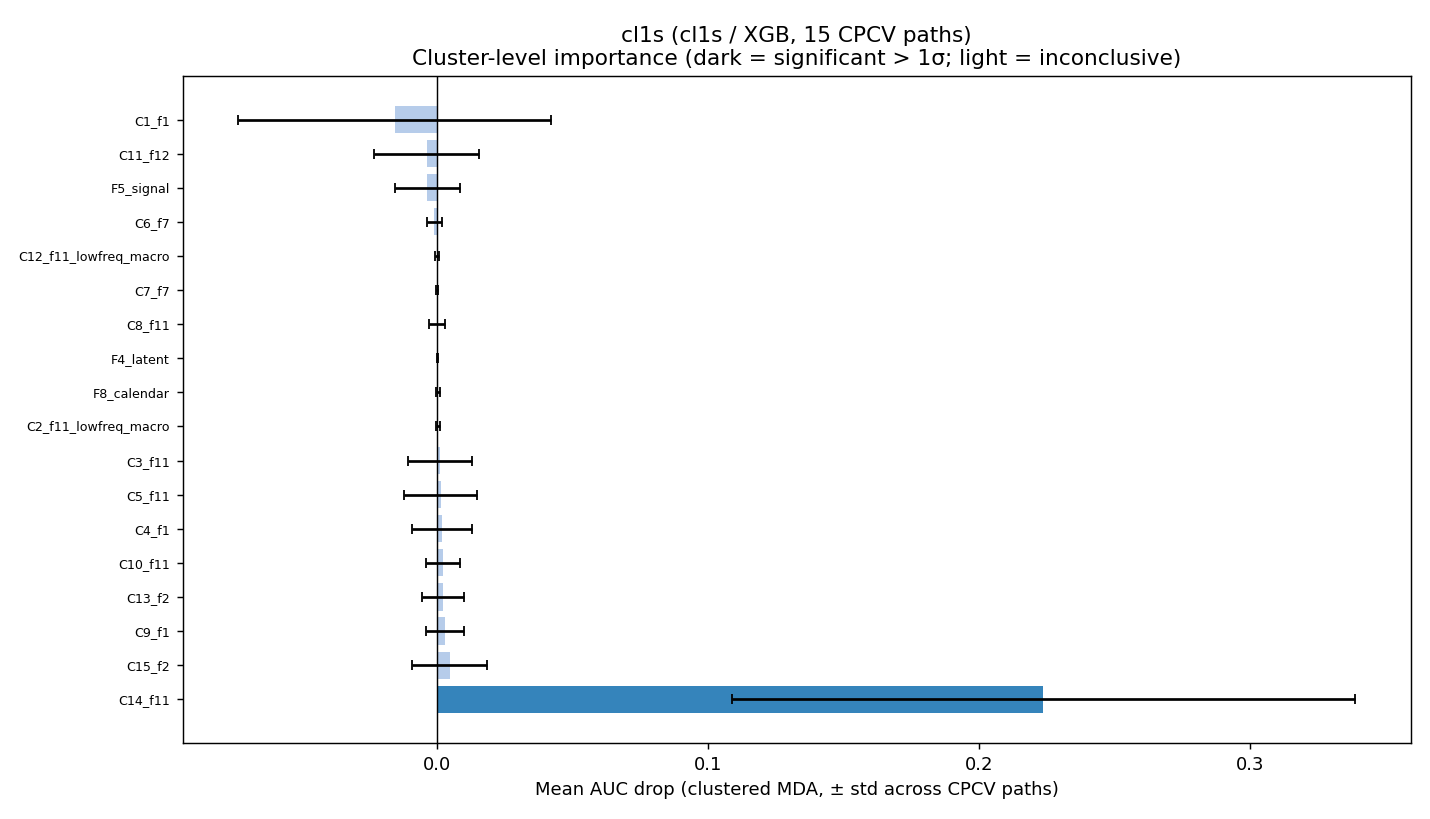

,cluster,mda_mean,mda_rank,mdi_sum,mdi_rank,shap_sum,shap_rank,significant
0,C14_f11,0.2238,1,0.4463,1,0.4469,1,True
1,C15_f2,0.0047,2,0.1595,2,0.0207,2,False
2,C9_f1,0.0030,3,0.0232,10,0.0029,12,False
3,C13_f2,0.0023,4,0.0486,5,0.0064,8,False
4,C10_f11,0.0021,5,0.0265,8,0.0136,5,False
5,C4_f1,0.0018,6,0.0260,9,0.0043,10,False
6,C5_f11,0.0013,7,0.0588,4,0.0106,7,False
7,C3_f11,0.0010,8,0.0724,3,0.0173,4,False
8,C2_f11_lowfreq_macro,0.0004,9,0.0030,18,0.0015,13,False
9,F8_calendar,0.0002,10,0.0106,12,0.0008,15,False



Kendall τ rank agreement:


,method_pair,kendall_tau,agree
0,MDA-MDI,0.33,False
1,MDA-SHAP,0.28,False
2,MDI-SHAP,0.71,True


In [3]:
show(BASE / 'cl1s' / 'clustered_mda_chart.png', width=1050)
cc = load(BASE / 'cl1s' / 'cluster_crosscheck_table.csv')
ra = load(BASE / 'cl1s' / 'rank_agreement.csv')
if not cc.empty:
    fmt = {'mda_mean': '{:.4f}'}
    for c in ['mdi_sum', 'shap_sum']:
        if c in cc.columns: fmt[c] = '{:.4f}'
    display(
        cc.style.format(fmt)
        .background_gradient(subset=['mda_mean'], cmap='RdYlGn', vmin=-0.05, vmax=0.25)
        .set_caption('cl1s — cluster cross-check (MDA · MDI · SHAP ranks)')
    )
if not ra.empty:
    print('\nKendall \u03c4 rank agreement:')
    display(ra.style.format({'kendall_tau': '{:.2f}'}))


### Step 3 · Within-cluster breakdown (top 3 by MDA)

Members ranked by mean |SHAP|. PCA on train submatrix.

**C14_f11** (the only significant cluster): `f11_move_z` and `f2_vol_60` dominate.
PC1 explains 67% — a single volatility-regime dimension.
`f11_move_z` and `f2_vol_60` load on opposite PC1 signs, suggesting they capture
complementary aspects of volatility (external fear index vs. realised crude vol).


,feature,mean_shap_mag,pc1_loading
0,f2_vol_60,0.1950,-0.468
1,f2_vol_of_vol_20,0.0163,-0.492
2,f11_move_z,0.2186,0.314
3,f11_move_vix_ratio,0.0156,0.435
4,f11_ust_bund_spread,0.0015,0.501


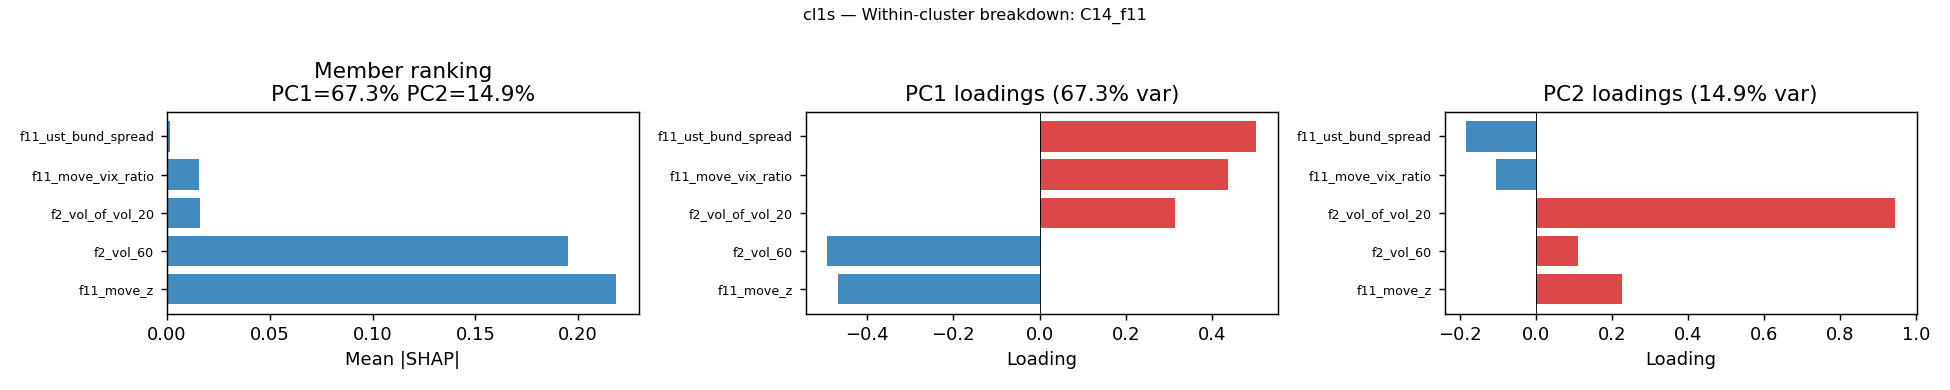

In [4]:
wc = load(BASE / 'cl1s' / 'within_cluster_C14_f11.csv')
if not wc.empty:
    pc1 = wc['pca_pc1_var_explained'].iloc[0]
    pc2v = wc.get('pca_pc2_var_explained', None)
    pc2 = pc2v.iloc[0] if pc2v is not None else float('nan')
    import math
    tier = '>= 65% single latent' if pc1 >= 0.65 else ('>= 40% dominant' if pc1 >= 0.40 else '< 40% multi-dim')
    pc2_str = f' PC2={pc2:.1%}' if not math.isnan(pc2) else ''
    label = f'PC1={pc1:.1%}{pc2_str} ({tier})'
    score_col = 'mean_shap_mag' if 'mean_shap_mag' in wc.columns else wc.columns[2]
    display(
        wc[['feature', score_col, 'pc1_loading']].style
        .format({score_col: '{:.4f}', 'pc1_loading': '{:.3f}'})
        .background_gradient(subset=[score_col], cmap='Blues')
        .set_caption(f'cl1s | C14_f11 — |SHAP| ranking + PC1 loadings  ({label})')
    )
show(BASE / 'cl1s' / 'within_cluster_C14_f11.png', width=950)


,feature,mean_shap_mag,pc1_loading
0,f2_vol_10,0.0002,0.413
1,f2_vol_20,0.0034,0.428
2,f2_vol_pctile_20,0.0000,0.340
3,f2_parkinson_20,0.0087,0.424
4,f2_garman_klass_20,0.0048,0.422
5,f10_hl_range,0.0000,0.303
6,hmm_vol_p0_calm,0.0005,-0.040
7,hmm_vol_p2_turbulent,0.0031,0.283


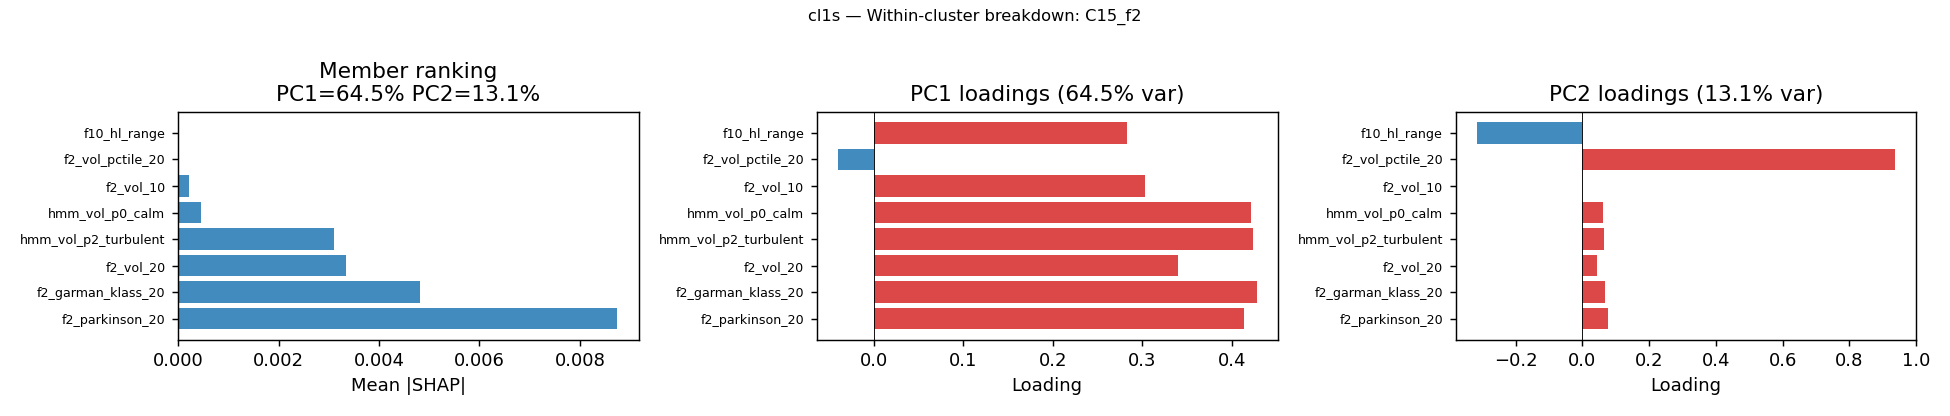

In [5]:
wc = load(BASE / 'cl1s' / 'within_cluster_C15_f2.csv')
if not wc.empty:
    pc1 = wc['pca_pc1_var_explained'].iloc[0]
    pc2v = wc.get('pca_pc2_var_explained', None)
    pc2 = pc2v.iloc[0] if pc2v is not None else float('nan')
    import math
    tier = '>= 65% single latent' if pc1 >= 0.65 else ('>= 40% dominant' if pc1 >= 0.40 else '< 40% multi-dim')
    pc2_str = f' PC2={pc2:.1%}' if not math.isnan(pc2) else ''
    label = f'PC1={pc1:.1%}{pc2_str} ({tier})'
    score_col = 'mean_shap_mag' if 'mean_shap_mag' in wc.columns else wc.columns[2]
    display(
        wc[['feature', score_col, 'pc1_loading']].style
        .format({score_col: '{:.4f}', 'pc1_loading': '{:.3f}'})
        .background_gradient(subset=[score_col], cmap='Blues')
        .set_caption(f'cl1s | C15_f2 — |SHAP| ranking + PC1 loadings  ({label})')
    )
show(BASE / 'cl1s' / 'within_cluster_C15_f2.png', width=950)


,feature,mean_shap_mag,pc1_loading
0,f1_bb_bandwidth_20,0.0009,0.694
1,f6_adx_14,0.0016,0.702
2,f13_path_tortuosity_20d,0.0005,-0.157


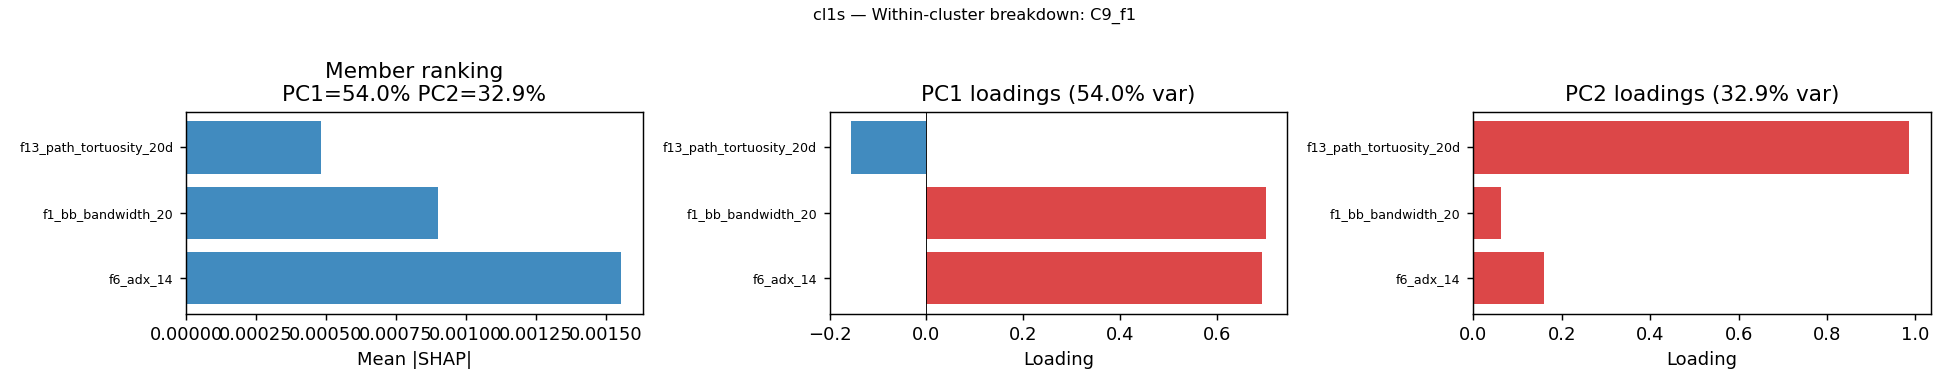

In [6]:
wc = load(BASE / 'cl1s' / 'within_cluster_C9_f1.csv')
if not wc.empty:
    pc1 = wc['pca_pc1_var_explained'].iloc[0]
    pc2v = wc.get('pca_pc2_var_explained', None)
    pc2 = pc2v.iloc[0] if pc2v is not None else float('nan')
    import math
    tier = '>= 65% single latent' if pc1 >= 0.65 else ('>= 40% dominant' if pc1 >= 0.40 else '< 40% multi-dim')
    pc2_str = f' PC2={pc2:.1%}' if not math.isnan(pc2) else ''
    label = f'PC1={pc1:.1%}{pc2_str} ({tier})'
    score_col = 'mean_shap_mag' if 'mean_shap_mag' in wc.columns else wc.columns[2]
    display(
        wc[['feature', score_col, 'pc1_loading']].style
        .format({score_col: '{:.4f}', 'pc1_loading': '{:.3f}'})
        .background_gradient(subset=[score_col], cmap='Blues')
        .set_caption(f'cl1s | C9_f1 — |SHAP| ranking + PC1 loadings  ({label})')
    )
show(BASE / 'cl1s' / 'within_cluster_C9_f1.png', width=950)


### Step 5 · Global per-feature SHAP

Mean |SHAP| per feature, averaged across 15 CPCV paths. Red = positive, blue = negative predictive direction.


,feature,shap_magnitude,shap_signed,mdi
0,f11_move_z,0.2186,0.1038,0.1389
1,f2_vol_60,0.1950,0.0736,0.1879
2,f2_vol_of_vol_20,0.0163,0.0038,0.0475
3,f11_move_vix_ratio,0.0156,-0.0067,0.0585
4,f11_ism_pmi_3m_change,0.0148,0.0068,0.0106
5,f11_vix_term_slope,0.0111,0.0065,0.0116
6,f2_parkinson_20,0.0087,-0.0082,0.0391
7,f6_macd_hist_12_26_9,0.0071,0.0009,0.0096
8,f15_ewma_implied_corr_z,0.0066,0.0023,0.0242
9,f2_garman_klass_20,0.0048,-0.0044,0.0441


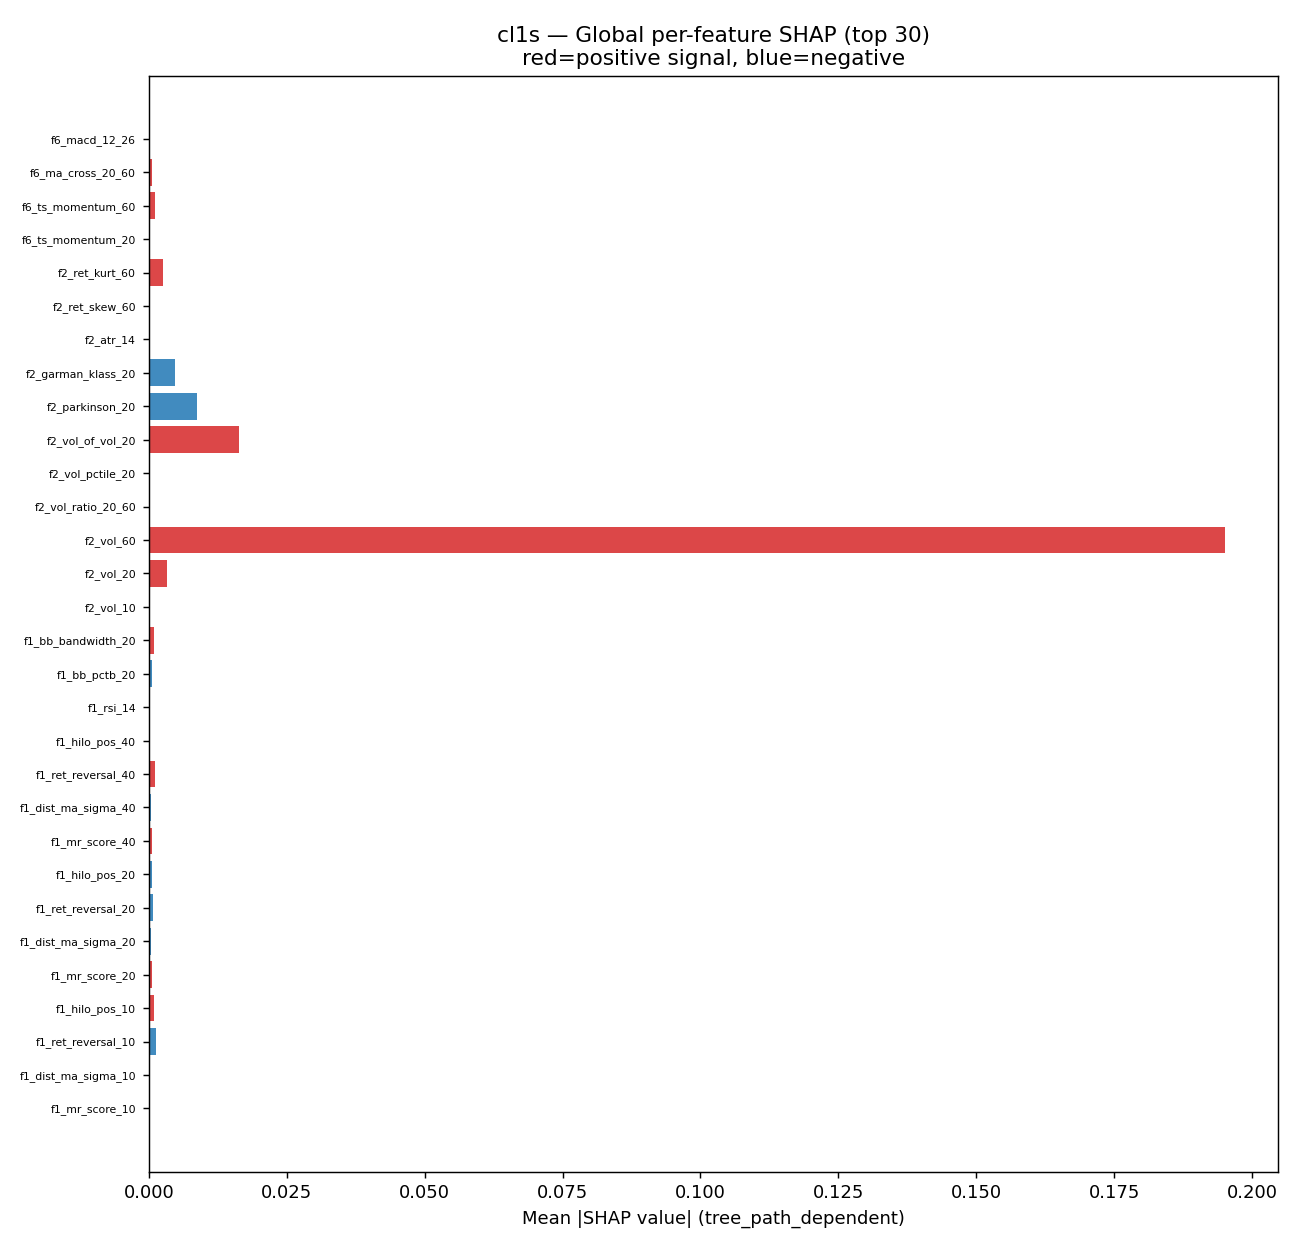

In [7]:
gs = load(BASE / 'cl1s' / 'global_shap_summary.csv')
if not gs.empty:
    display(
        gs.head(25).style
        .format({'shap_magnitude': '{:.4f}', 'shap_signed': '{:.4f}', 'mdi': '{:.4f}'})
        .background_gradient(subset=['shap_magnitude'], cmap='Blues')
        .set_caption('cl1s — top 25 features by mean|SHAP|')
    )
show(BASE / 'cl1s' / 'global_shap_chart.png', width=1000)


---
## HO1S — champion: `energy_all` / Logistic (elastic-net)

**CPCV:** 15 paths · AUC 0.698 ± 0.303 · **NO SIGNAL** (lower CI 0.50, marginal)

**Significant clusters:** none. All cluster MDA standard deviations exceed means.

> ho1s uses the **pooled `energy_all` model** (all 4 energy instruments combined);
> importance is scored on the **ho1s slice** of each CPCV test fold.
> The CPCV AUC variance (±0.303) is very high — the pooled model occasionally achieves
> strong ho1s discrimination in some fold combinations by chance, but not reliably.
> No cluster is significant; MDA–Coef agreement is poor (τ=0.31).
> Results are included for completeness only — no structure should be inferred.
> The top cluster by raw MDA (F5_signal, 0.173) has std=0.268, larger than its mean.


### Step 1 · Feature clusters


,cluster,n_members,dominant_pfx,purity,mean_drop,std_drop,significant
16,F5_signal,5,f5_,100%,0.1735,0.2682,False
3,C13_f11,6,f11_,67%,0.0906,0.2226,False
11,C6_f2,4,f2_,50%,0.0616,0.1619,False
2,C12_f11_lowfreq_macro,2,f11_,100%,0.0341,0.0589,False
8,C3_f6,7,f6_,43%,0.0224,0.0659,False
12,C7_f11_lowfreq_macro,2,f11_,100%,0.0142,0.0551,False
7,C2_f1,10,f1_,70%,0.0112,0.1061,False
0,C10_f11,10,f11_,30%,0.0109,0.1216,False
9,C4_f2,15,f2_,47%,0.0095,0.0146,False
4,C14_f7,2,f7_,100%,0.0040,0.0185,False


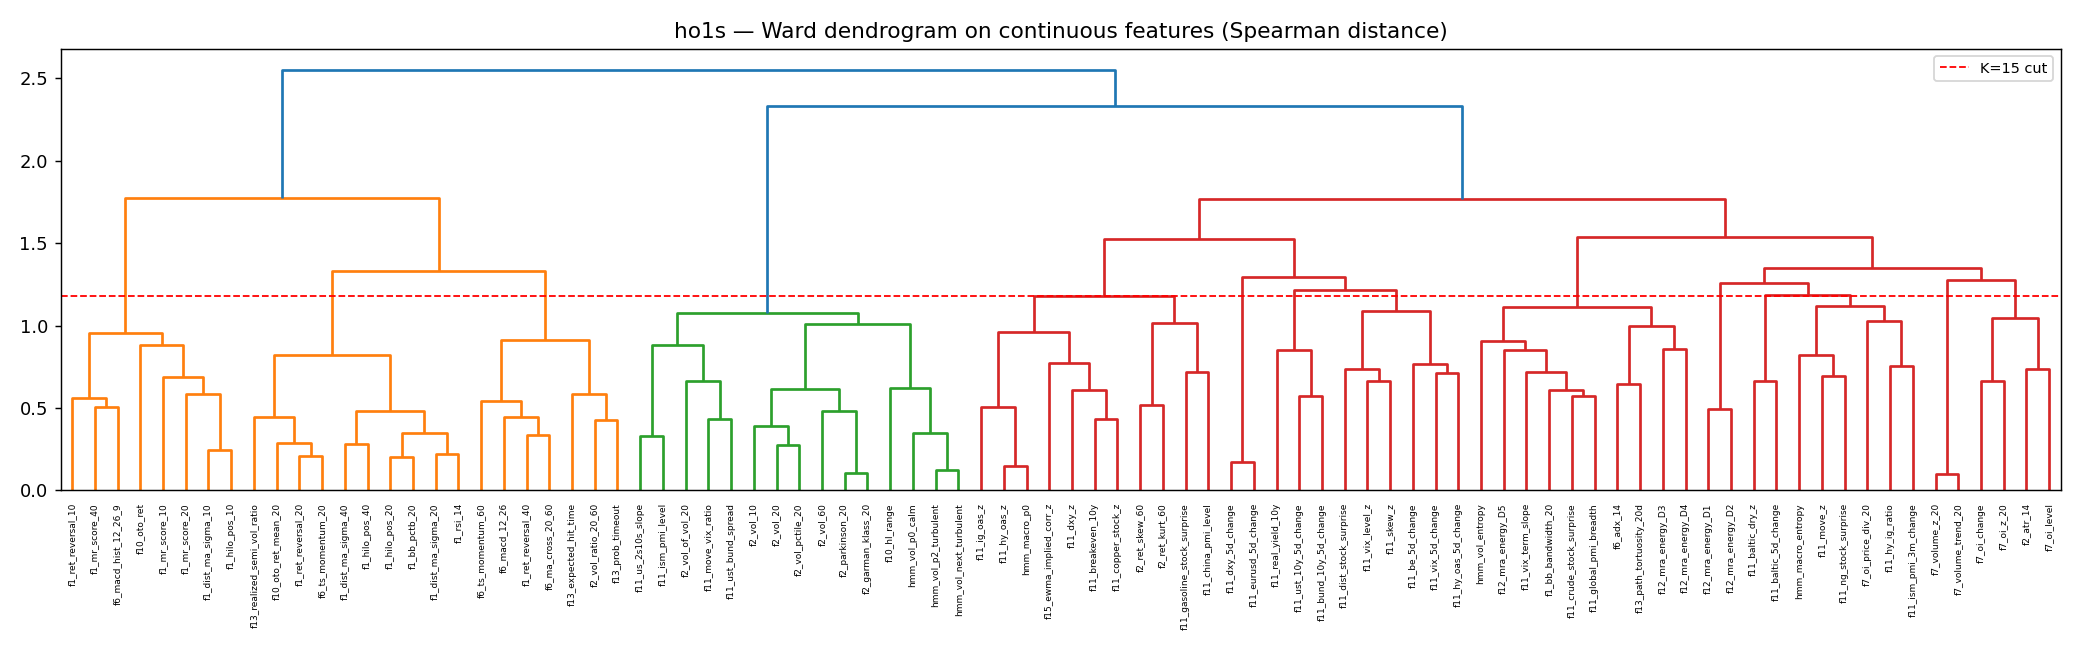

In [8]:
cs = cluster_summary('ho1s')
display(
    cs.style
    .format({'mean_drop': '{:.4f}', 'std_drop': '{:.4f}', 'purity': '{:.0%}'})
    .background_gradient(subset=['mean_drop'], cmap='RdYlGn', vmin=-0.05, vmax=0.20)
    .set_caption('ho1s — cluster summary (energy_all pool, K=15 corr + 4 hand-assigned = 19 groups)')
)
show(BASE / 'ho1s' / 'dendrogram.png', width=1100)


### Step 2 · Cluster-level importance

No significant clusters. MDA–Coef agreement poor (τ=0.31).


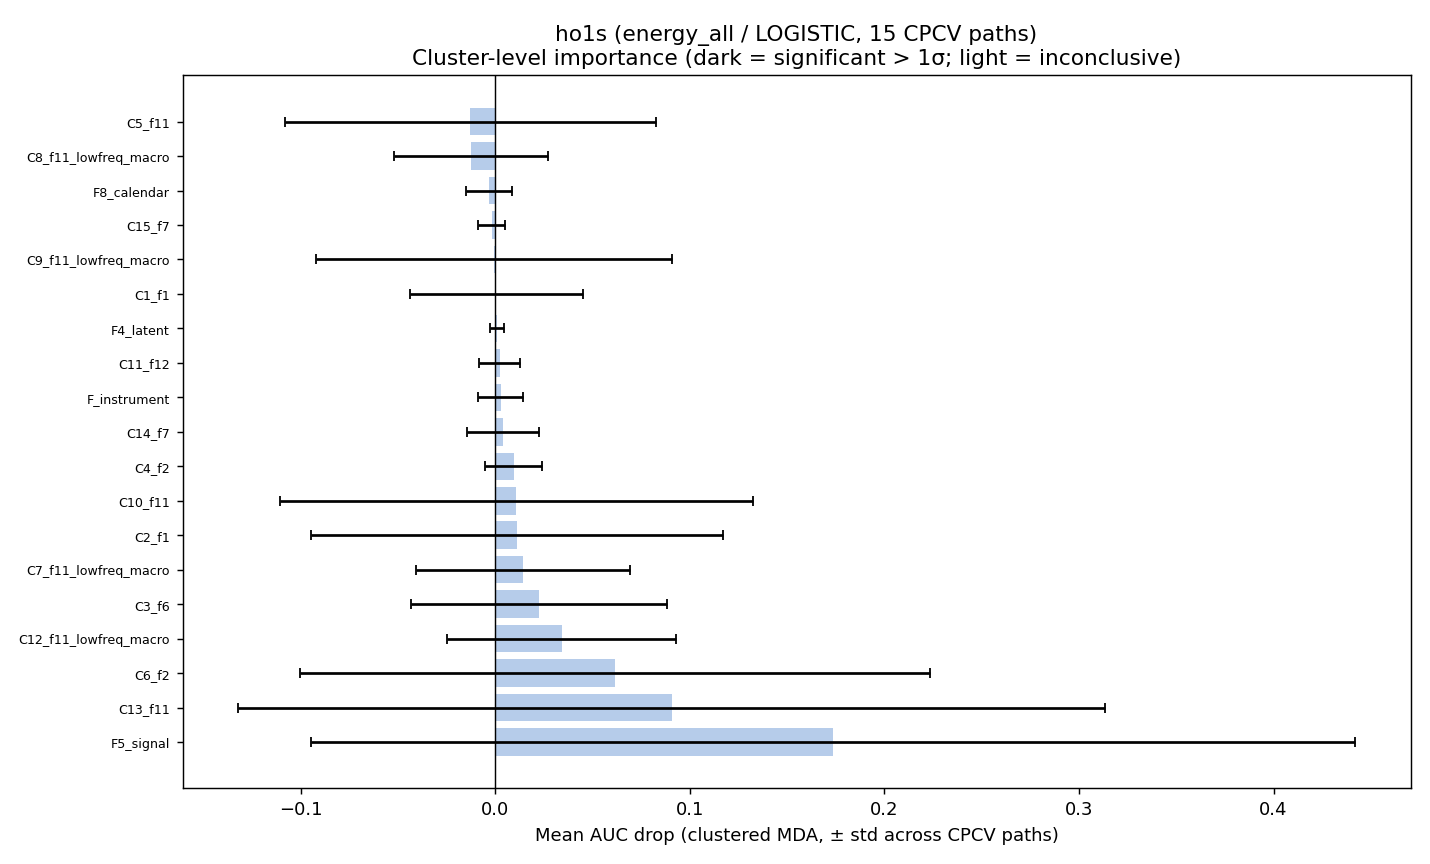

,cluster,mda_mean,mda_rank,coef_sum,coef_rank,significant
0,F5_signal,0.1735,1,0.7454,1,False
1,C13_f11,0.0906,2,0.5610,2,False
2,C6_f2,0.0616,3,0.2108,10,False
3,C12_f11_lowfreq_macro,0.0341,4,0.1609,11,False
4,C3_f6,0.0224,5,0.4427,4,False
5,C7_f11_lowfreq_macro,0.0142,6,0.0939,15,False
6,C2_f1,0.0112,7,0.4410,5,False
7,C10_f11,0.0109,8,0.4493,3,False
8,C4_f2,0.0095,9,0.4119,7,False
9,C14_f7,0.0040,10,0.0295,19,False



Kendall τ rank agreement (MDA vs Coef):


,method_pair,kendall_tau,agree
0,MDA-Coef,0.31,False


In [9]:
show(BASE / 'ho1s' / 'clustered_mda_chart.png', width=1050)
cc = load(BASE / 'ho1s' / 'cluster_crosscheck_table.csv')
ra = load(BASE / 'ho1s' / 'rank_agreement.csv')
if not cc.empty:
    fmt = {'mda_mean': '{:.4f}'}
    if 'coef_sum' in cc.columns: fmt['coef_sum'] = '{:.4f}'
    display(
        cc.style.format(fmt)
        .background_gradient(subset=['mda_mean'], cmap='RdYlGn', vmin=-0.05, vmax=0.20)
        .set_caption('ho1s — cluster cross-check (MDA · Coef; elastic-net logistic, energy_all pool)')
    )
if not ra.empty:
    print('\nKendall \u03c4 rank agreement (MDA vs Coef):')
    display(ra.style.format({'kendall_tau': '{:.2f}'}))


### Step 3 · Within-cluster breakdown (top 3 by raw MDA)

Members ranked by mean |coef|. PCA on train submatrix. No clusters are significant —
breakdowns shown for completeness only.


,feature,mean_coef_abs,pc1_loading
0,f5_signal,0.4706,0.570
1,f5_trailing_run_length,0.0258,0.465
2,f5_participation_20,0.0236,0.229
3,f5_long_bias_20,0.1050,0.622
4,f5_sign_agree_mr,0.0165,-0.140


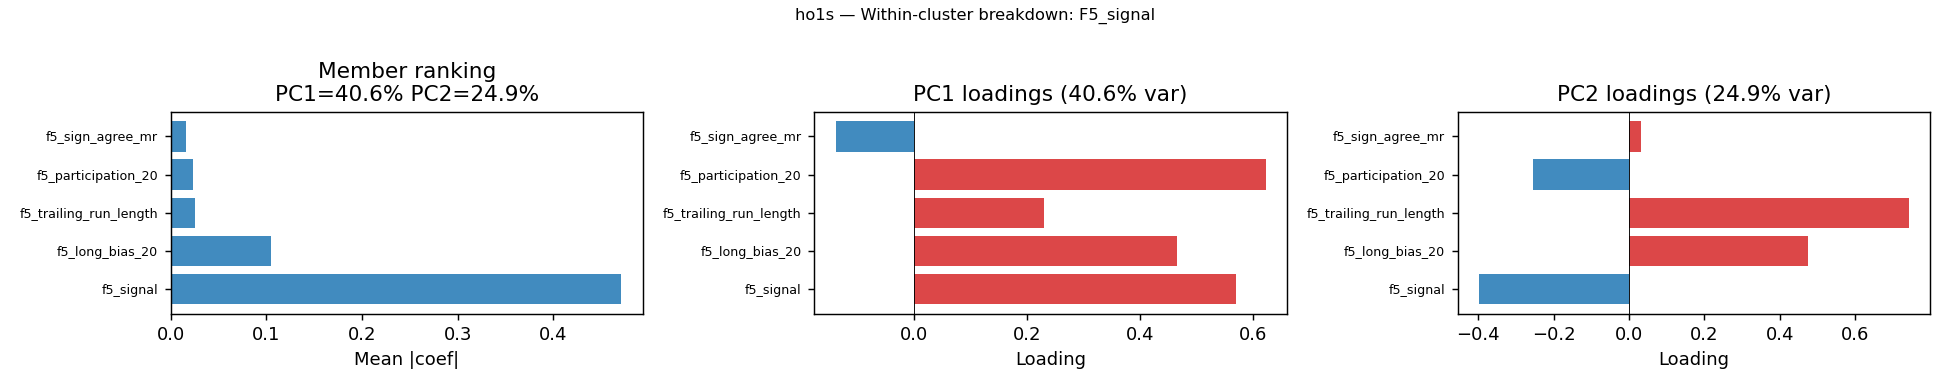

In [10]:
wc = load(BASE / 'ho1s' / 'within_cluster_F5_signal.csv')
if not wc.empty:
    pc1 = wc['pca_pc1_var_explained'].iloc[0]
    pc2v = wc.get('pca_pc2_var_explained', None)
    pc2 = pc2v.iloc[0] if pc2v is not None else float('nan')
    import math
    tier = '>= 65% single latent' if pc1 >= 0.65 else ('>= 40% dominant' if pc1 >= 0.40 else '< 40% multi-dim')
    pc2_str = f' PC2={pc2:.1%}' if not math.isnan(pc2) else ''
    label = f'PC1={pc1:.1%}{pc2_str} ({tier})'
    score_col = 'mean_coef_abs' if 'mean_coef_abs' in wc.columns else wc.columns[2]
    display(
        wc[['feature', score_col, 'pc1_loading']].style
        .format({score_col: '{:.4f}', 'pc1_loading': '{:.3f}'})
        .background_gradient(subset=[score_col], cmap='Blues')
        .set_caption(f'ho1s | F5_signal — |coef| ranking + PC1 loadings  ({label})')
    )
show(BASE / 'ho1s' / 'within_cluster_F5_signal.png', width=950)


,feature,mean_coef_abs,pc1_loading
0,f7_oi_price_div_20,0.0875,0.069
1,f11_move_z,0.3936,0.245
2,f11_hy_ig_ratio,0.0073,0.431
3,f11_ng_stock_surprise,0.0098,-0.458
4,f11_ism_pmi_3m_change,0.0452,0.593
5,hmm_macro_entropy,0.0026,-0.434


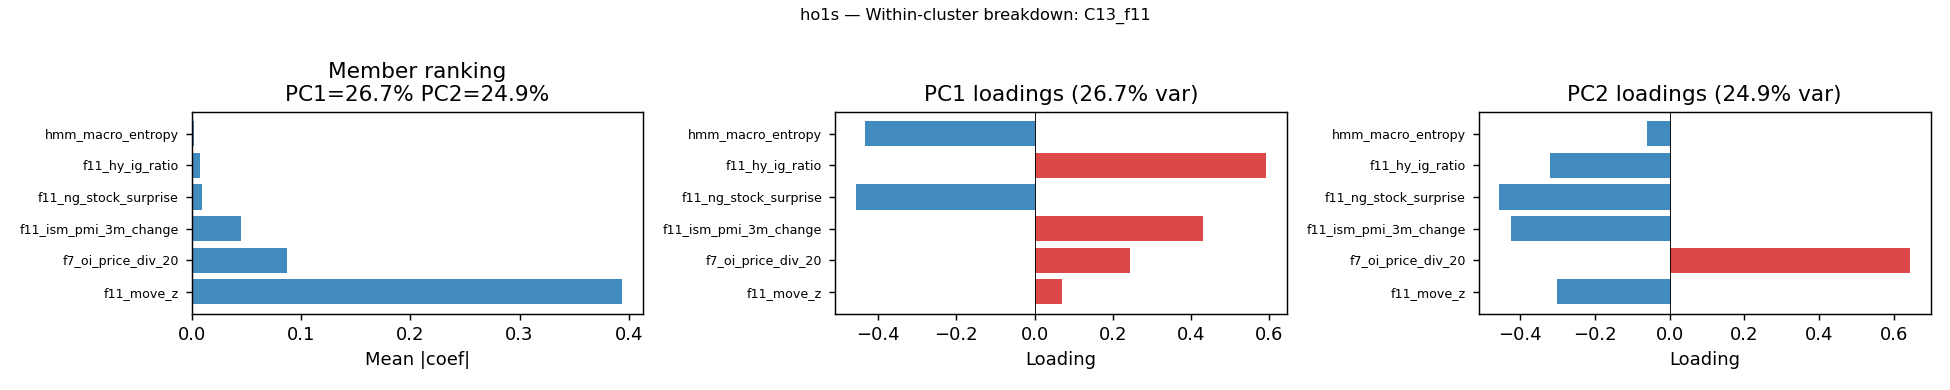

In [11]:
wc = load(BASE / 'ho1s' / 'within_cluster_C13_f11.csv')
if not wc.empty:
    pc1 = wc['pca_pc1_var_explained'].iloc[0]
    pc2v = wc.get('pca_pc2_var_explained', None)
    pc2 = pc2v.iloc[0] if pc2v is not None else float('nan')
    import math
    tier = '>= 65% single latent' if pc1 >= 0.65 else ('>= 40% dominant' if pc1 >= 0.40 else '< 40% multi-dim')
    pc2_str = f' PC2={pc2:.1%}' if not math.isnan(pc2) else ''
    label = f'PC1={pc1:.1%}{pc2_str} ({tier})'
    score_col = 'mean_coef_abs' if 'mean_coef_abs' in wc.columns else wc.columns[2]
    display(
        wc[['feature', score_col, 'pc1_loading']].style
        .format({score_col: '{:.4f}', 'pc1_loading': '{:.3f}'})
        .background_gradient(subset=[score_col], cmap='Blues')
        .set_caption(f'ho1s | C13_f11 — |coef| ranking + PC1 loadings  ({label})')
    )
show(BASE / 'ho1s' / 'within_cluster_C13_f11.png', width=950)


,feature,mean_coef_abs,pc1_loading
0,f2_ret_skew_60,0.0504,0.588
1,f2_ret_kurt_60,0.0029,-0.584
2,f11_gasoline_stock_surprise,0.1040,0.297
3,f11_china_pmi_level,0.0204,0.475


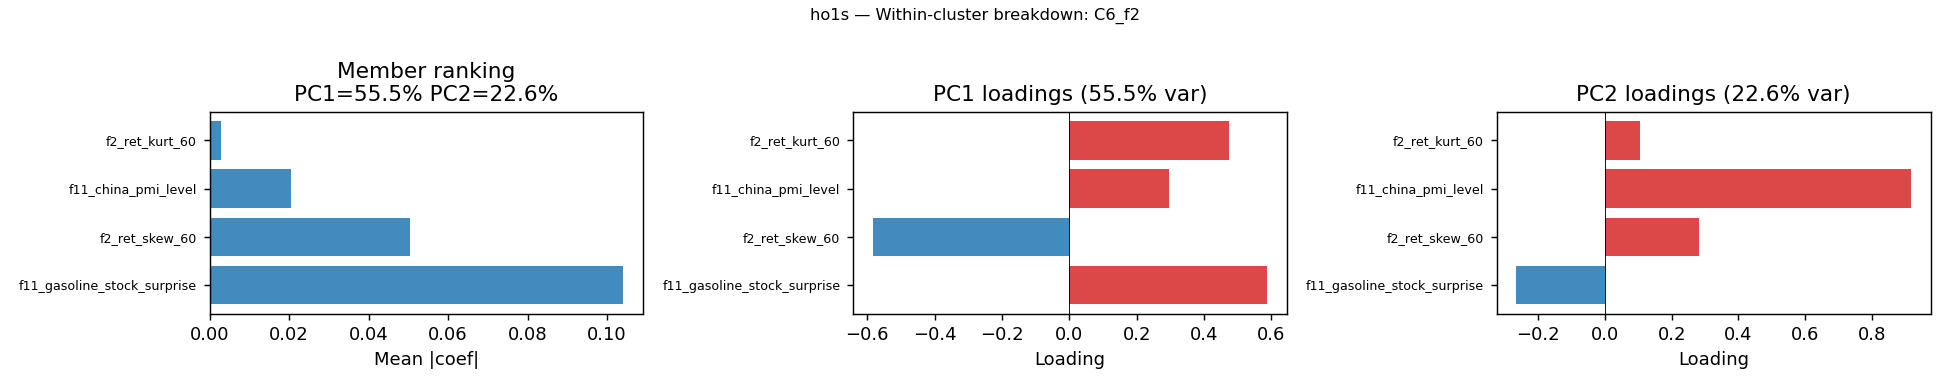

In [12]:
wc = load(BASE / 'ho1s' / 'within_cluster_C6_f2.csv')
if not wc.empty:
    pc1 = wc['pca_pc1_var_explained'].iloc[0]
    pc2v = wc.get('pca_pc2_var_explained', None)
    pc2 = pc2v.iloc[0] if pc2v is not None else float('nan')
    import math
    tier = '>= 65% single latent' if pc1 >= 0.65 else ('>= 40% dominant' if pc1 >= 0.40 else '< 40% multi-dim')
    pc2_str = f' PC2={pc2:.1%}' if not math.isnan(pc2) else ''
    label = f'PC1={pc1:.1%}{pc2_str} ({tier})'
    score_col = 'mean_coef_abs' if 'mean_coef_abs' in wc.columns else wc.columns[2]
    display(
        wc[['feature', score_col, 'pc1_loading']].style
        .format({score_col: '{:.4f}', 'pc1_loading': '{:.3f}'})
        .background_gradient(subset=[score_col], cmap='Blues')
        .set_caption(f'ho1s | C6_f2 — |coef| ranking + PC1 loadings  ({label})')
    )
show(BASE / 'ho1s' / 'within_cluster_C6_f2.png', width=950)


### Step 5 · Global per-feature coefficient

Mean |standardised coefficient| per feature. Shown for structural reference;
no predictive interpretation is warranted given the lack of confirmed signal.


,feature,coef_abs,coef_signed
0,f5_signal,0.4706,0.4706
1,f11_move_z,0.3936,-0.3936
2,f2_vol_ratio_20_60,0.1614,-0.1614
3,f1_bb_pctb_20,0.1535,-0.1535
4,f1_mr_score_20,0.1371,-0.1371
5,f1_rsi_14,0.1249,-0.1249
6,f6_ts_momentum_60,0.1210,-0.1210
7,f11_baltic_5d_change,0.1172,0.1172
8,f5_long_bias_20,0.1050,-0.1050
9,f11_ism_pmi_level,0.1042,0.1042


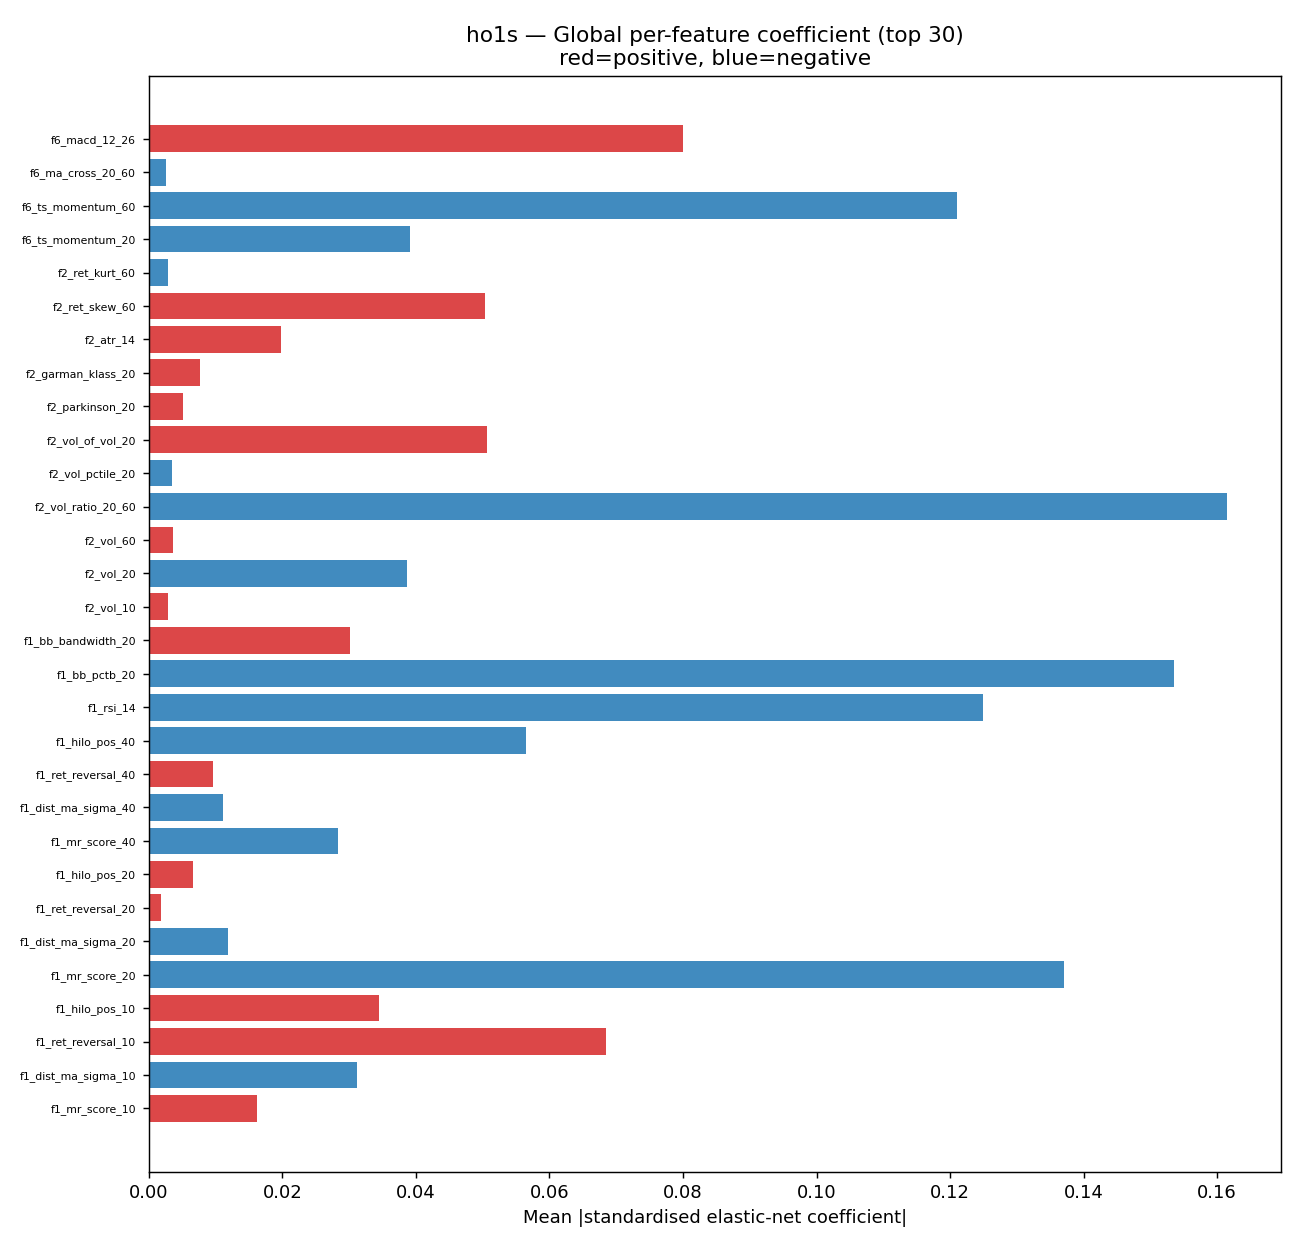

In [13]:
gc = load(BASE / 'ho1s' / 'global_coef_summary.csv')
if not gc.empty:
    display(
        gc.head(25).style
        .format({'coef_abs': '{:.4f}', 'coef_signed': '{:.4f}'})
        .background_gradient(subset=['coef_abs'], cmap='Blues')
        .set_caption('ho1s — top 25 features by mean |coef| (NO SIGNAL — illustrative only)')
    )
show(BASE / 'ho1s' / 'global_coef_chart.png', width=1000)


---
## RB1S — champion: `energy_all` / Logistic (elastic-net)

**CPCV:** 15 paths · AUC 0.582 ± 0.094 · **NO SIGNAL** (lower CI 0.46)

**Significant clusters:** F5\_signal (MDA 0.092 ± 0.088) and C13\_f11 (MDA 0.073 ± 0.069) — both barely significant (mean ≈ std).

> rb1s shares the `energy_all` pool with ho1s/ng1s. Two clusters are technically significant
> (mean > std) but the instrument has no confirmed OOS signal (lower CI = 0.46). The significance
> likely reflects the pooled model finding some rb1s-relevant structure in the training data
> that doesn't survive OOS. MDA–Coef agreement is very poor (τ=0.17) — the elastic-net
> coefficients rank features differently than the permutation test, suggesting regularisation
> is suppressing features that matter for rb1s specifically.
> C13_f11 contains `f11_move_z` (coefficient 0.394 >> rest) but C13's PC1 explains only
> 27% of variance — a genuinely multi-dimensional cluster.


### Step 1 · Feature clusters


,cluster,n_members,dominant_pfx,purity,mean_drop,std_drop,significant
16,F5_signal,5,f5_,100%,0.0920,0.0876,True
3,C13_f11,6,f11_,67%,0.0732,0.0686,True
9,C4_f2,15,f2_,47%,0.0076,0.0223,False
8,C3_f6,7,f6_,43%,0.0045,0.0107,False
11,C6_f2,4,f2_,50%,0.0031,0.0306,False
18,F_instrument,3,inst_,100%,0.0025,0.0073,False
6,C1_f1,8,f1_,75%,0.0005,0.0100,False
1,C11_f12,2,f12_,100%,-0.0000,0.0023,False
5,C15_f7,4,f7_,75%,-0.0003,0.0009,False
12,C7_f11_lowfreq_macro,2,f11_,100%,-0.0004,0.0024,False


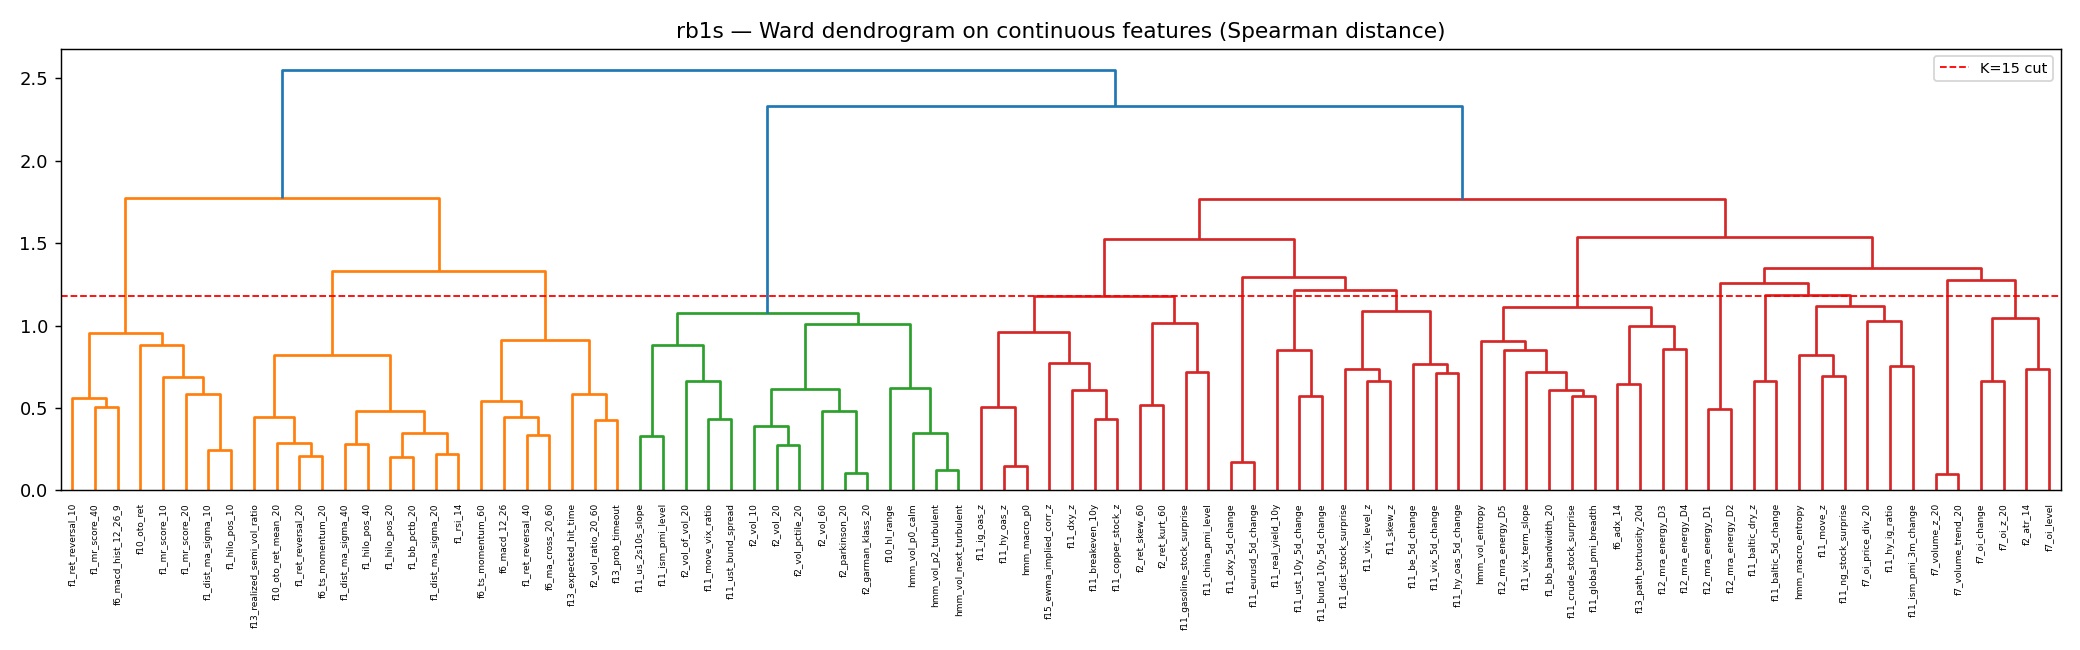

In [14]:
cs = cluster_summary('rb1s')
display(
    cs.style
    .format({'mean_drop': '{:.4f}', 'std_drop': '{:.4f}', 'purity': '{:.0%}'})
    .background_gradient(subset=['mean_drop'], cmap='RdYlGn', vmin=-0.05, vmax=0.12)
    .set_caption('rb1s — cluster summary (energy_all pool, K=15 corr + 4 hand-assigned = 19 groups)')
)
show(BASE / 'rb1s' / 'dendrogram.png', width=1100)


### Step 2 · Cluster-level importance

Two clusters reach significance (mean > std). MDA–Coef agreement poor (τ=0.17).


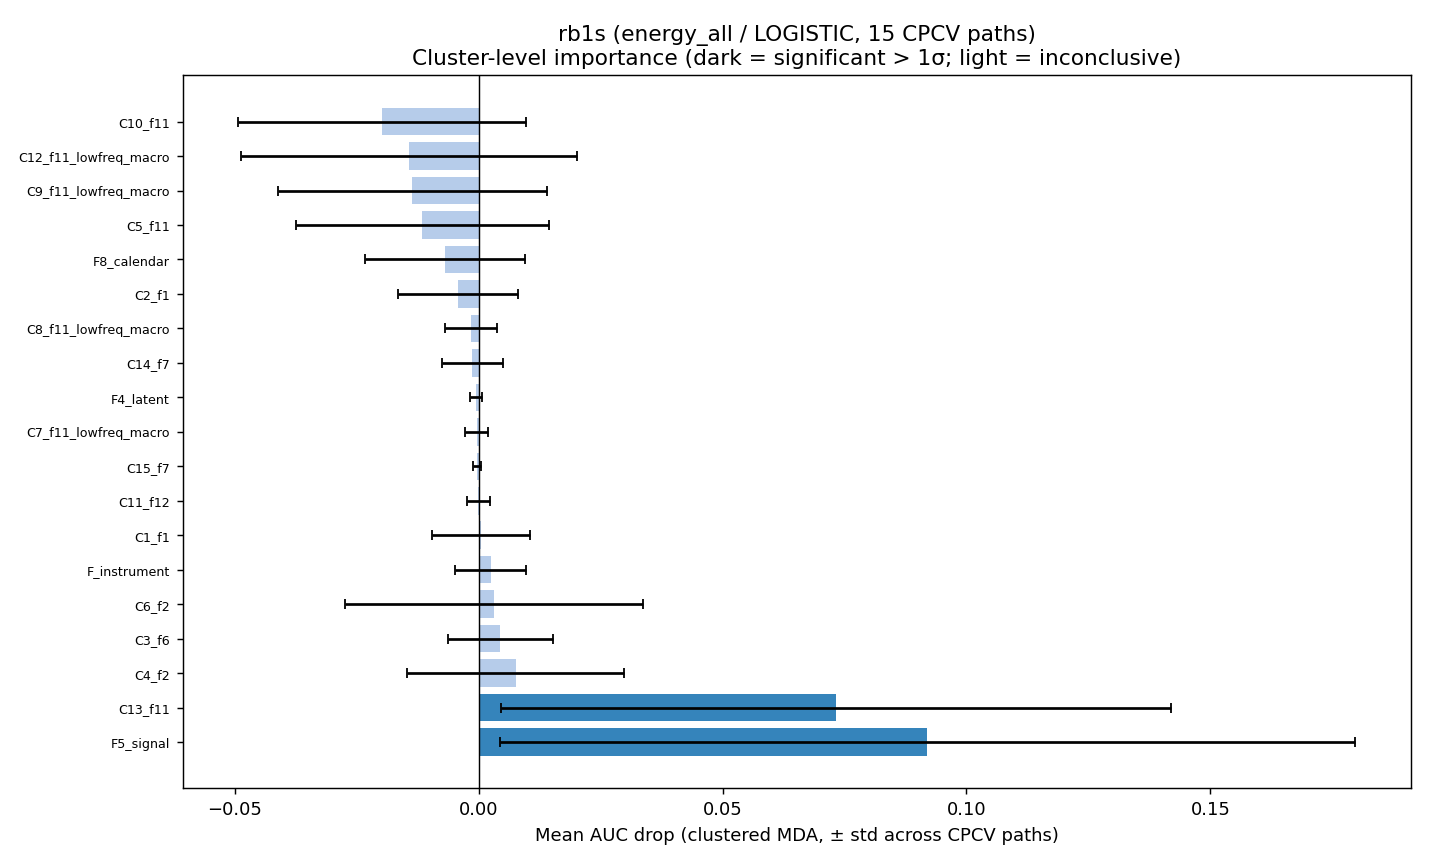

,cluster,mda_mean,mda_rank,coef_sum,coef_rank,significant
0,F5_signal,0.0920,1,0.7454,1,True
1,C13_f11,0.0732,2,0.5610,2,True
2,C4_f2,0.0076,3,0.4119,7,False
3,C3_f6,0.0045,4,0.4427,4,False
4,C6_f2,0.0031,5,0.2108,10,False
5,F_instrument,0.0025,6,0.1235,14,False
6,C1_f1,0.0005,7,0.4156,6,False
7,C11_f12,-0.0000,8,0.0383,17,False
8,C15_f7,-0.0003,9,0.0736,16,False
9,C7_f11_lowfreq_macro,-0.0004,10,0.0939,15,False



Kendall τ rank agreement (MDA vs Coef):


,method_pair,kendall_tau,agree
0,MDA-Coef,0.17,False


In [15]:
show(BASE / 'rb1s' / 'clustered_mda_chart.png', width=1050)
cc = load(BASE / 'rb1s' / 'cluster_crosscheck_table.csv')
ra = load(BASE / 'rb1s' / 'rank_agreement.csv')
if not cc.empty:
    fmt = {'mda_mean': '{:.4f}'}
    if 'coef_sum' in cc.columns: fmt['coef_sum'] = '{:.4f}'
    display(
        cc.style.format(fmt)
        .background_gradient(subset=['mda_mean'], cmap='RdYlGn', vmin=-0.05, vmax=0.12)
        .set_caption('rb1s — cluster cross-check (MDA · Coef; elastic-net logistic, energy_all pool)')
    )
if not ra.empty:
    print('\nKendall \u03c4 rank agreement (MDA vs Coef):')
    display(ra.style.format({'kendall_tau': '{:.2f}'}))


### Step 3 · Within-cluster breakdown (significant clusters first, then top by MDA)

Members ranked by mean |coef|. PCA on train submatrix.


,feature,mean_coef_abs,pc1_loading
0,f5_signal,0.4706,0.570
1,f5_trailing_run_length,0.0258,0.465
2,f5_participation_20,0.0236,0.229
3,f5_long_bias_20,0.1050,0.622
4,f5_sign_agree_mr,0.0165,-0.140


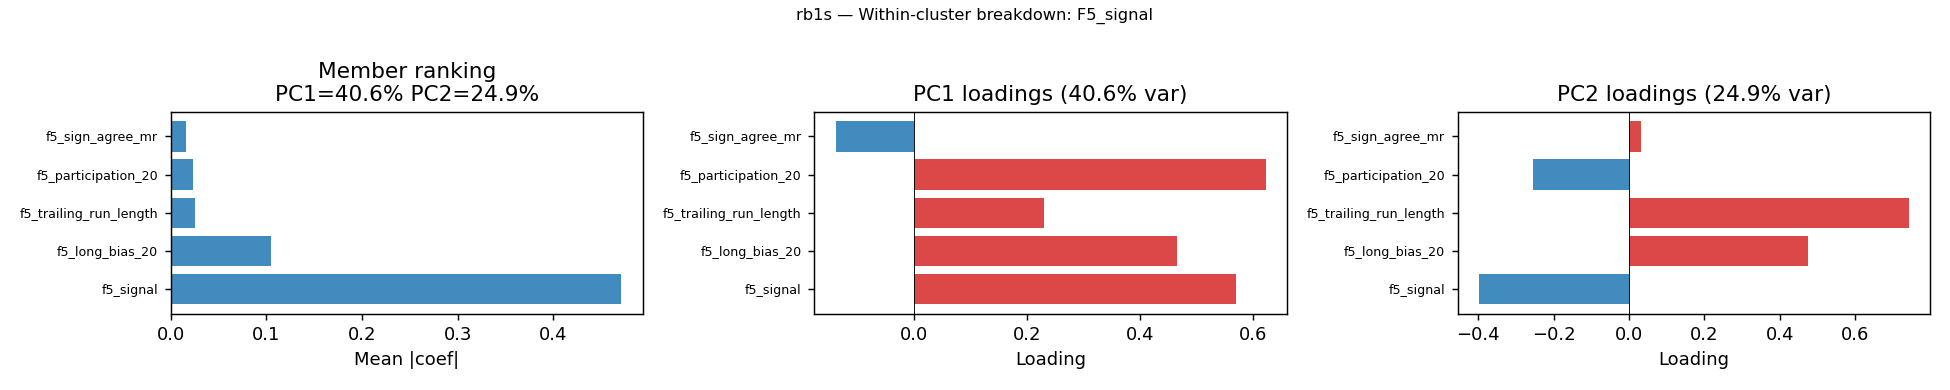

In [16]:
wc = load(BASE / 'rb1s' / 'within_cluster_F5_signal.csv')
if not wc.empty:
    pc1 = wc['pca_pc1_var_explained'].iloc[0]
    pc2v = wc.get('pca_pc2_var_explained', None)
    pc2 = pc2v.iloc[0] if pc2v is not None else float('nan')
    import math
    tier = '>= 65% single latent' if pc1 >= 0.65 else ('>= 40% dominant' if pc1 >= 0.40 else '< 40% multi-dim')
    pc2_str = f' PC2={pc2:.1%}' if not math.isnan(pc2) else ''
    label = f'PC1={pc1:.1%}{pc2_str} ({tier})'
    score_col = 'mean_coef_abs' if 'mean_coef_abs' in wc.columns else wc.columns[2]
    display(
        wc[['feature', score_col, 'pc1_loading']].style
        .format({score_col: '{:.4f}', 'pc1_loading': '{:.3f}'})
        .background_gradient(subset=[score_col], cmap='Blues')
        .set_caption(f'rb1s | F5_signal — |coef| ranking + PC1 loadings  ({label})')
    )
show(BASE / 'rb1s' / 'within_cluster_F5_signal.png', width=950)


,feature,mean_coef_abs,pc1_loading
0,f7_oi_price_div_20,0.0875,0.069
1,f11_move_z,0.3936,0.245
2,f11_hy_ig_ratio,0.0073,0.431
3,f11_ng_stock_surprise,0.0098,-0.458
4,f11_ism_pmi_3m_change,0.0452,0.593
5,hmm_macro_entropy,0.0026,-0.434


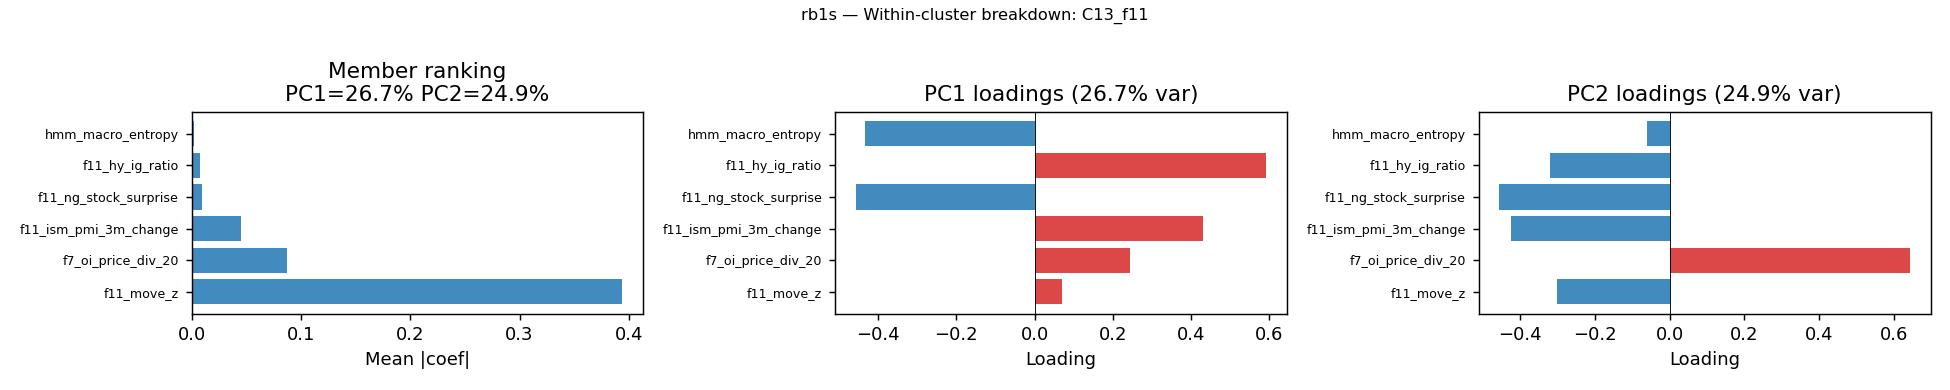

In [17]:
wc = load(BASE / 'rb1s' / 'within_cluster_C13_f11.csv')
if not wc.empty:
    pc1 = wc['pca_pc1_var_explained'].iloc[0]
    pc2v = wc.get('pca_pc2_var_explained', None)
    pc2 = pc2v.iloc[0] if pc2v is not None else float('nan')
    import math
    tier = '>= 65% single latent' if pc1 >= 0.65 else ('>= 40% dominant' if pc1 >= 0.40 else '< 40% multi-dim')
    pc2_str = f' PC2={pc2:.1%}' if not math.isnan(pc2) else ''
    label = f'PC1={pc1:.1%}{pc2_str} ({tier})'
    score_col = 'mean_coef_abs' if 'mean_coef_abs' in wc.columns else wc.columns[2]
    display(
        wc[['feature', score_col, 'pc1_loading']].style
        .format({score_col: '{:.4f}', 'pc1_loading': '{:.3f}'})
        .background_gradient(subset=[score_col], cmap='Blues')
        .set_caption(f'rb1s | C13_f11 — |coef| ranking + PC1 loadings  ({label})')
    )
show(BASE / 'rb1s' / 'within_cluster_C13_f11.png', width=950)


,feature,mean_coef_abs,pc1_loading
0,f2_vol_10,0.0028,0.281
1,f2_vol_20,0.0387,0.303
2,f2_vol_60,0.0036,0.296
3,f2_vol_pctile_20,0.0034,0.257
4,f2_vol_of_vol_20,0.0506,0.259
5,f2_parkinson_20,0.0051,0.299
6,f2_garman_klass_20,0.0076,0.296
7,f10_hl_range,0.0101,0.215
8,f11_move_vix_ratio,0.0272,-0.198
9,f11_us_2s10s_slope,0.0635,-0.215


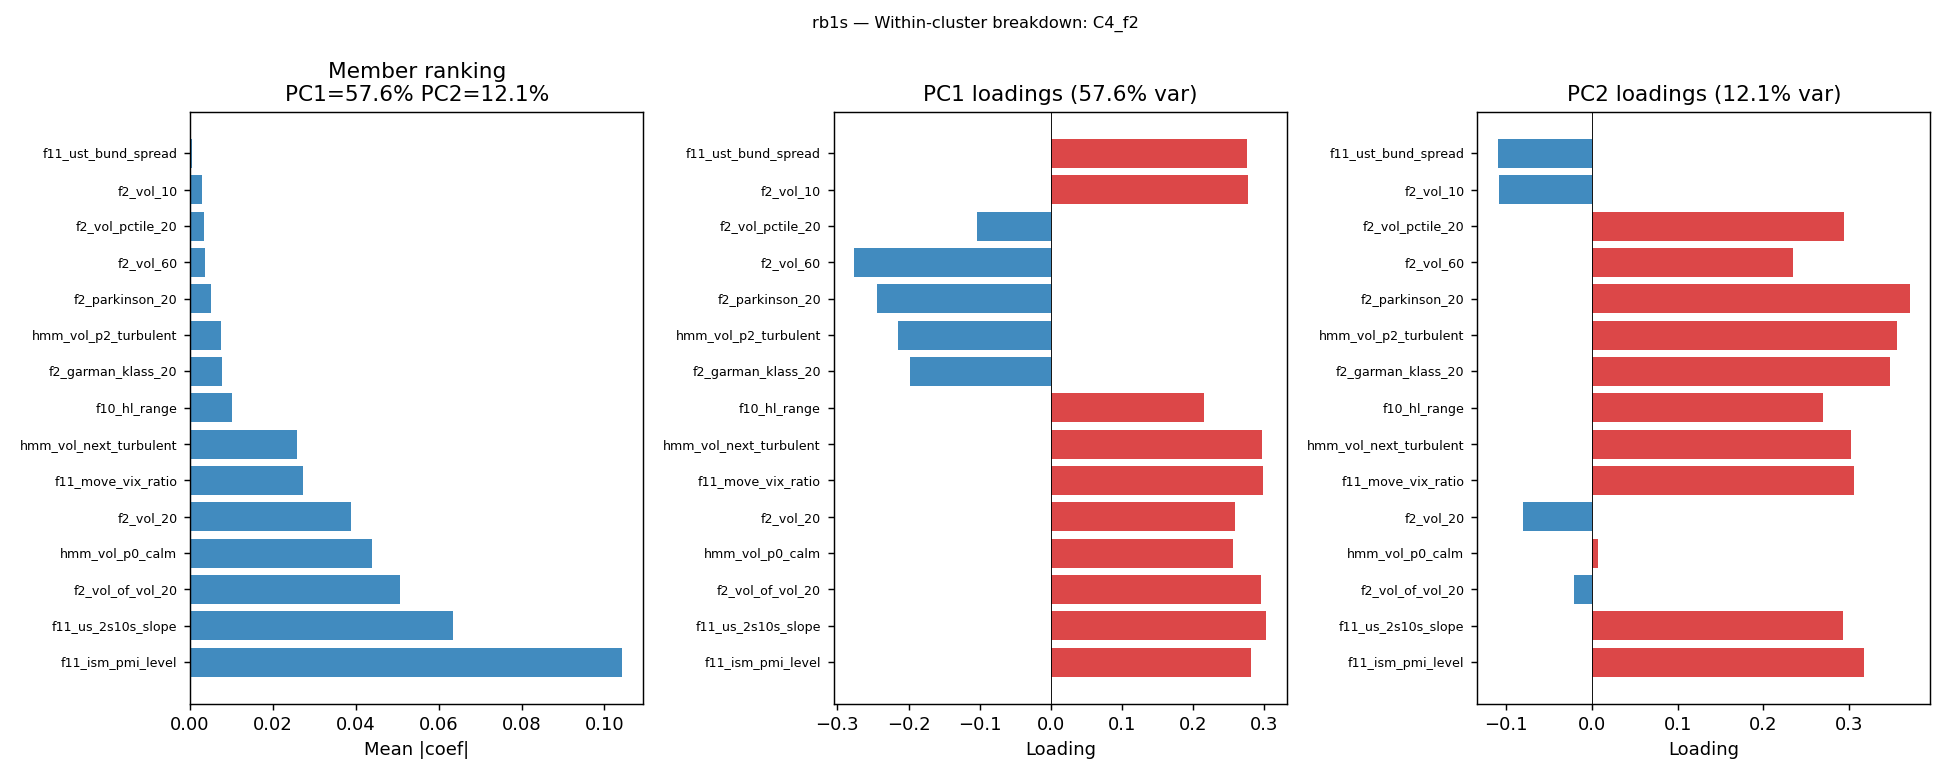

In [18]:
wc = load(BASE / 'rb1s' / 'within_cluster_C4_f2.csv')
if not wc.empty:
    pc1 = wc['pca_pc1_var_explained'].iloc[0]
    pc2v = wc.get('pca_pc2_var_explained', None)
    pc2 = pc2v.iloc[0] if pc2v is not None else float('nan')
    import math
    tier = '>= 65% single latent' if pc1 >= 0.65 else ('>= 40% dominant' if pc1 >= 0.40 else '< 40% multi-dim')
    pc2_str = f' PC2={pc2:.1%}' if not math.isnan(pc2) else ''
    label = f'PC1={pc1:.1%}{pc2_str} ({tier})'
    score_col = 'mean_coef_abs' if 'mean_coef_abs' in wc.columns else wc.columns[2]
    display(
        wc[['feature', score_col, 'pc1_loading']].style
        .format({score_col: '{:.4f}', 'pc1_loading': '{:.3f}'})
        .background_gradient(subset=[score_col], cmap='Blues')
        .set_caption(f'rb1s | C4_f2 — |coef| ranking + PC1 loadings  ({label})')
    )
show(BASE / 'rb1s' / 'within_cluster_C4_f2.png', width=950)


### Step 5 · Global per-feature coefficient

Mean |standardised coefficient| per feature. No confirmed signal — shown for contrast.


,feature,coef_abs,coef_signed
0,f5_signal,0.4706,0.4706
1,f11_move_z,0.3936,-0.3936
2,f2_vol_ratio_20_60,0.1614,-0.1614
3,f1_bb_pctb_20,0.1535,-0.1535
4,f1_mr_score_20,0.1371,-0.1371
5,f1_rsi_14,0.1249,-0.1249
6,f6_ts_momentum_60,0.1210,-0.1210
7,f11_baltic_5d_change,0.1172,0.1172
8,f5_long_bias_20,0.1050,-0.1050
9,f11_ism_pmi_level,0.1042,0.1042


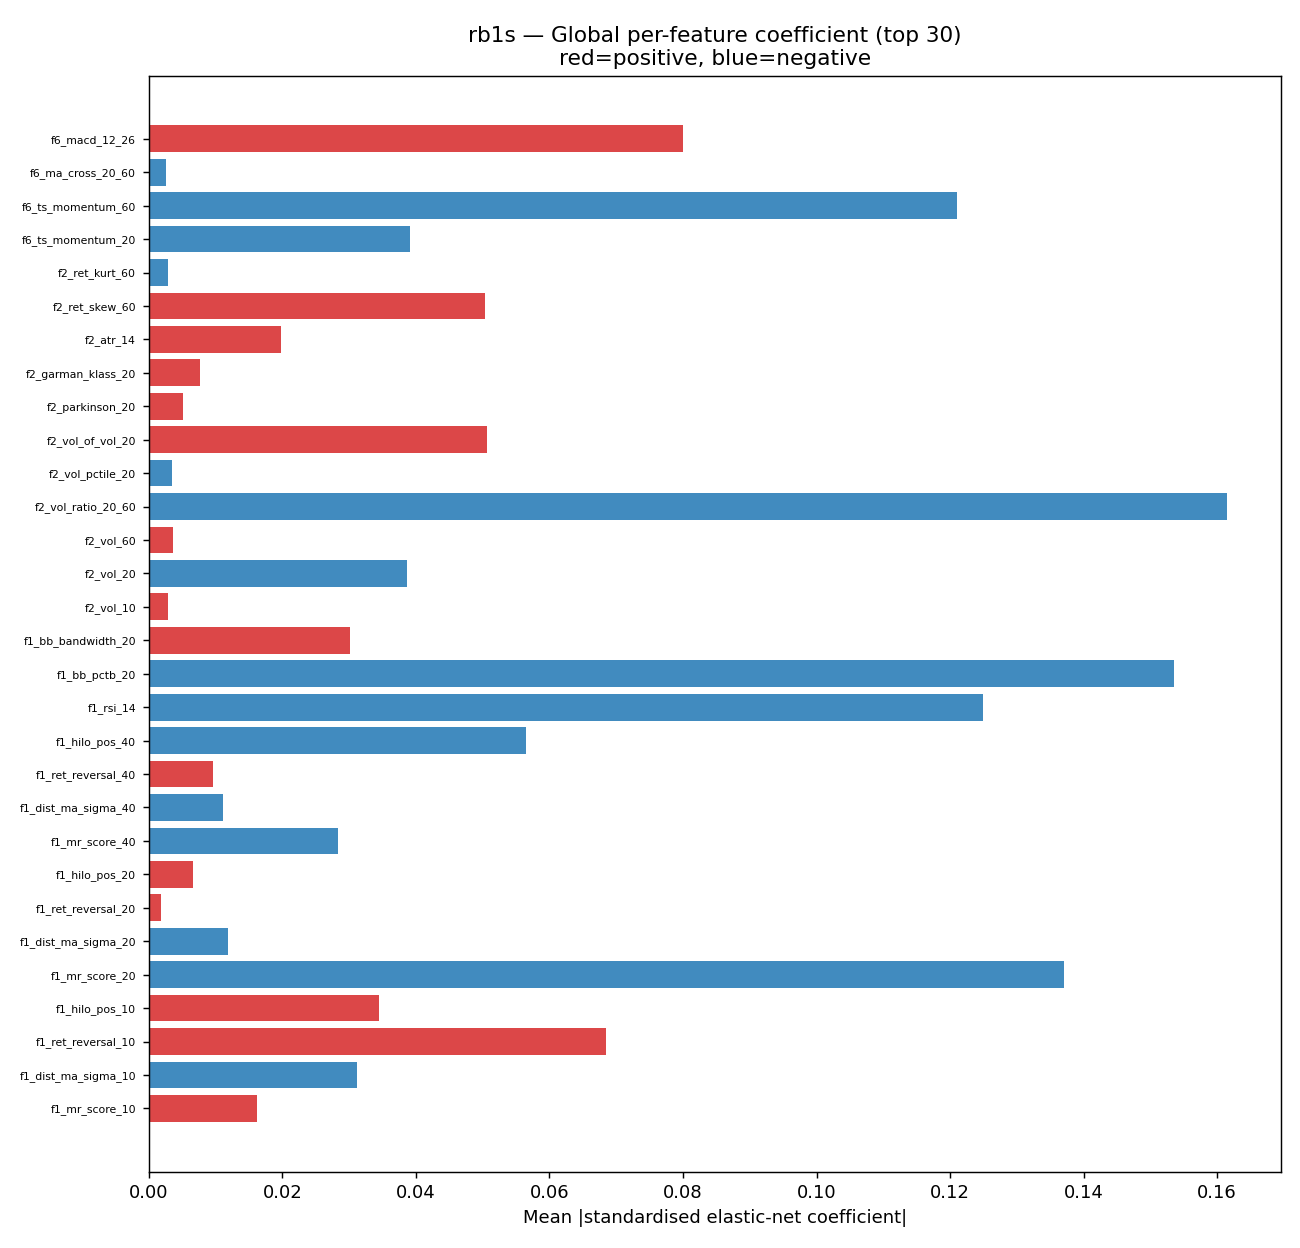

In [19]:
gc = load(BASE / 'rb1s' / 'global_coef_summary.csv')
if not gc.empty:
    display(
        gc.head(25).style
        .format({'coef_abs': '{:.4f}', 'coef_signed': '{:.4f}'})
        .background_gradient(subset=['coef_abs'], cmap='Blues')
        .set_caption('rb1s — top 25 features by mean |coef| (NO SIGNAL — illustrative only)')
    )
show(BASE / 'rb1s' / 'global_coef_chart.png', width=1000)


---
## NG1S — champion: `energy_all` / RF

**CPCV:** 12 paths (3 skipped) · AUC 0.409 ± 0.259 · **NO SIGNAL** (lower CI 0.22)

**Significant clusters:** none.

> ng1s has ~28 train events at the global cut (too thin for individual modelling, hence carried
> by `energy_all`). 3 of 15 CPCV folds were skipped because the ng1s test slice had fewer than
> 2 class labels. Mean AUC = 0.409 — below random, consistent with no signal. MDI–SHAP agree
> strongly (τ=0.87), which simply reflects the RF's consistent internal feature ranking —
> not predictive usefulness. MDA–MDI (τ=−0.17) and MDA–SHAP (τ=−0.18) actually disagree,
> indicating permutation-based importance is independent noise.
> Results are shown for diagnostic completeness only.


### Step 1 · Feature clusters


,cluster,n_members,dominant_pfx,purity,mean_drop,std_drop,significant
3,C13_f11,6,f11_,67%,0.0735,0.0801,False
14,C9_f11_lowfreq_macro,6,f11_,100%,0.0249,0.0595,False
11,C6_f2,4,f2_,50%,0.0126,0.0631,False
8,C3_f6,7,f6_,43%,0.0092,0.0585,False
1,C11_f12,2,f12_,100%,0.0055,0.0218,False
10,C5_f11,7,f11_,71%,0.0039,0.0412,False
18,F_instrument,3,inst_,100%,0.0030,0.0183,False
15,F4_latent,4,f4_,100%,0.0016,0.0162,False
17,F8_calendar,4,f8_,100%,0.0012,0.0082,False
4,C14_f7,2,f7_,100%,0.0002,0.0144,False


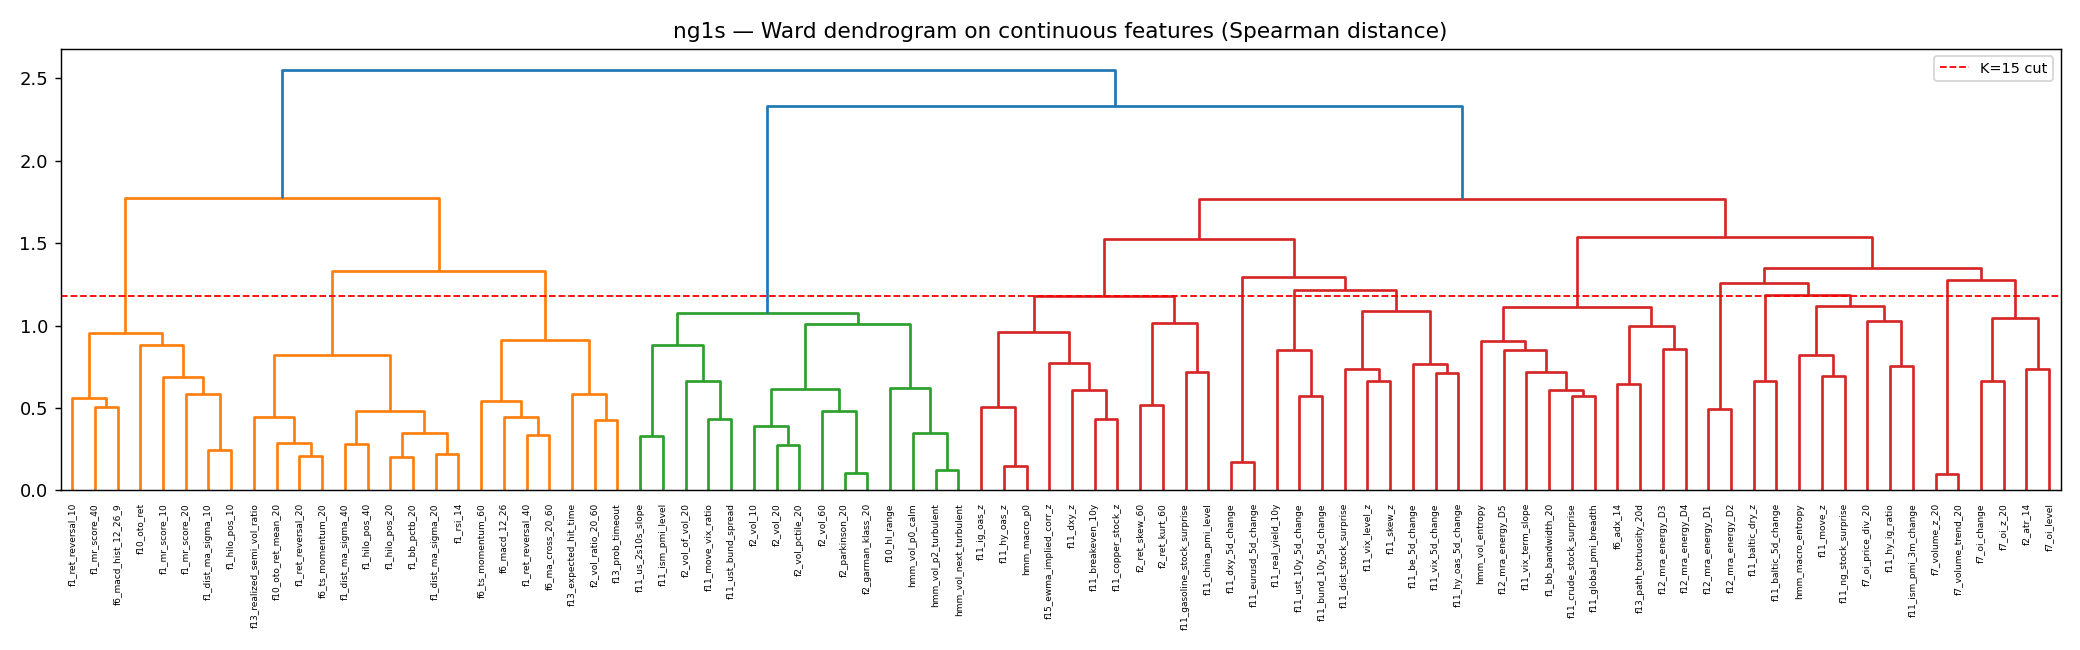

In [20]:
cs = cluster_summary('ng1s')
display(
    cs.style
    .format({'mean_drop': '{:.4f}', 'std_drop': '{:.4f}', 'purity': '{:.0%}'})
    .background_gradient(subset=['mean_drop'], cmap='RdYlGn', vmin=-0.10, vmax=0.10)
    .set_caption('ng1s — cluster summary (energy_all pool, K=15 corr + 4 hand-assigned = 19 groups)')
)
show(BASE / 'ng1s' / 'dendrogram.png', width=1100)


### Step 2 · Cluster-level importance

No significant clusters. MDA–MDI and MDA–SHAP disagree (negative τ).


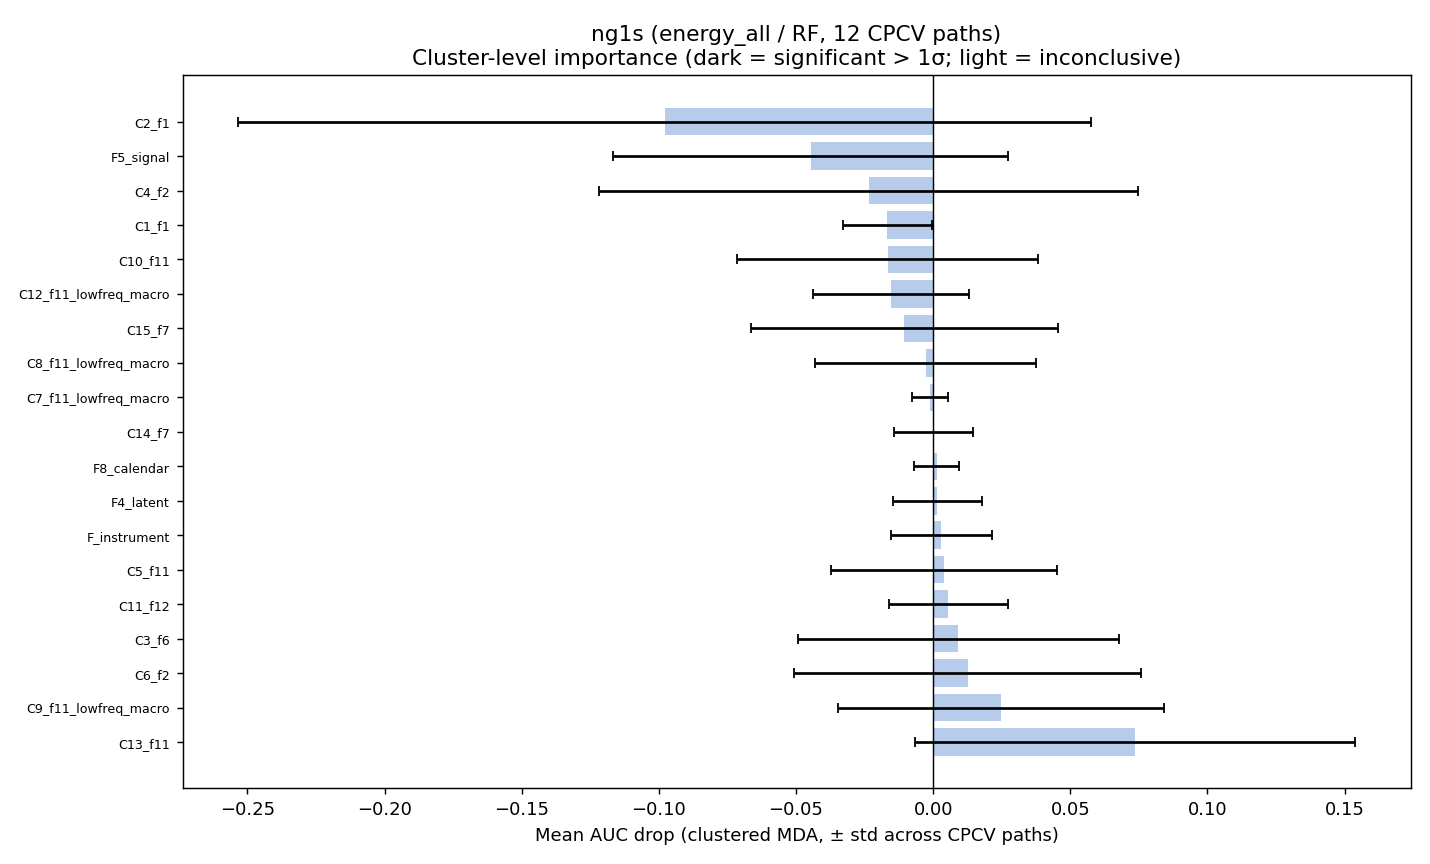

,cluster,mda_mean,mda_rank,mdi_sum,mdi_rank,shap_sum,shap_rank,significant
0,C13_f11,0.0735,1,0.1007,2,0.0301,3,False
1,C9_f11_lowfreq_macro,0.0249,2,0.0548,10,0.0101,11,False
2,C6_f2,0.0126,3,0.0574,8,0.0143,9,False
3,C3_f6,0.0092,4,0.0558,9,0.0148,8,False
4,C11_f12,0.0055,5,0.0165,15,0.0030,16,False
5,C5_f11,0.0039,6,0.0746,5,0.0177,7,False
6,F_instrument,0.0030,7,0.0073,18,0.0029,17,False
7,F4_latent,0.0016,8,0.0333,13,0.0060,13,False
8,F8_calendar,0.0012,9,0.0111,17,0.0039,15,False
9,C14_f7,0.0002,10,0.0041,19,0.0014,19,False



Kendall τ rank agreement:


,method_pair,kendall_tau,agree
0,MDA-MDI,-0.17,False
1,MDA-SHAP,-0.18,False
2,MDI-SHAP,0.87,True


In [21]:
show(BASE / 'ng1s' / 'clustered_mda_chart.png', width=1050)
cc = load(BASE / 'ng1s' / 'cluster_crosscheck_table.csv')
ra = load(BASE / 'ng1s' / 'rank_agreement.csv')
if not cc.empty:
    fmt = {'mda_mean': '{:.4f}'}
    for c in ['mdi_sum', 'shap_sum']: 
        if c in cc.columns: fmt[c] = '{:.4f}'
    display(
        cc.style.format(fmt)
        .background_gradient(subset=['mda_mean'], cmap='RdYlGn', vmin=-0.10, vmax=0.10)
        .set_caption('ng1s — cluster cross-check (MDA · MDI · SHAP ranks; RF, energy_all pool)')
    )
if not ra.empty:
    print('\nKendall \u03c4 rank agreement:')
    display(ra.style.format({'kendall_tau': '{:.2f}'}))


### Step 3 · Within-cluster breakdown (top 3 by raw MDA)

Members ranked by mean |SHAP|. No significant clusters — shown for diagnostic reference only.


,feature,mean_shap_mag,pc1_loading
0,f7_oi_price_div_20,0.0010,0.069
1,f11_move_z,0.0168,0.245
2,f11_hy_ig_ratio,0.0020,0.431
3,f11_ng_stock_surprise,0.0048,-0.458
4,f11_ism_pmi_3m_change,0.0006,0.593
5,hmm_macro_entropy,0.0050,-0.434


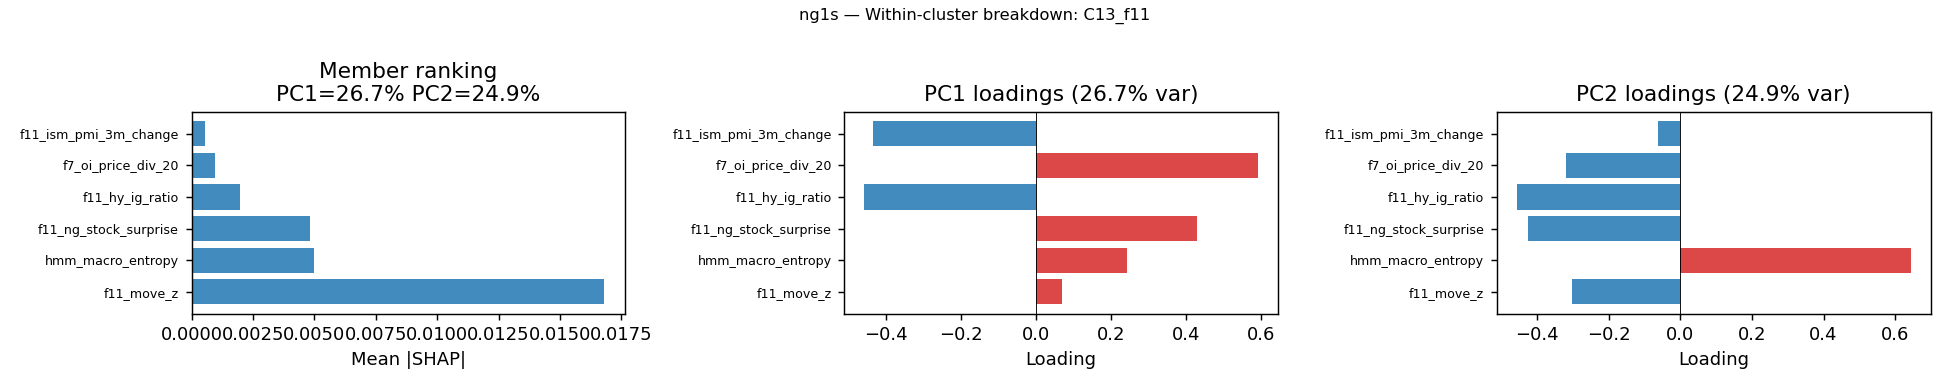

In [22]:
wc = load(BASE / 'ng1s' / 'within_cluster_C13_f11.csv')
if not wc.empty:
    pc1 = wc['pca_pc1_var_explained'].iloc[0]
    pc2v = wc.get('pca_pc2_var_explained', None)
    pc2 = pc2v.iloc[0] if pc2v is not None else float('nan')
    import math
    tier = '>= 65% single latent' if pc1 >= 0.65 else ('>= 40% dominant' if pc1 >= 0.40 else '< 40% multi-dim')
    pc2_str = f' PC2={pc2:.1%}' if not math.isnan(pc2) else ''
    label = f'PC1={pc1:.1%}{pc2_str} ({tier})'
    score_col = 'mean_shap_mag' if 'mean_shap_mag' in wc.columns else wc.columns[2]
    display(
        wc[['feature', score_col, 'pc1_loading']].style
        .format({score_col: '{:.4f}', 'pc1_loading': '{:.3f}'})
        .background_gradient(subset=[score_col], cmap='Blues')
        .set_caption(f'ng1s | C13_f11 — |SHAP| ranking + PC1 loadings  ({label})')
    )
show(BASE / 'ng1s' / 'within_cluster_C13_f11.png', width=950)


,feature,mean_shap_mag,pc1_loading
0,f11_vix_level_z,0.0019,0.494
1,f11_vix_5d_change,0.0011,0.450
2,f11_skew_z,0.0011,-0.358
3,f11_be_5d_change,0.0007,-0.400
4,f11_hy_oas_5d_change,0.0016,0.417
5,f11_dist_stock_surprise,0.0038,-0.304


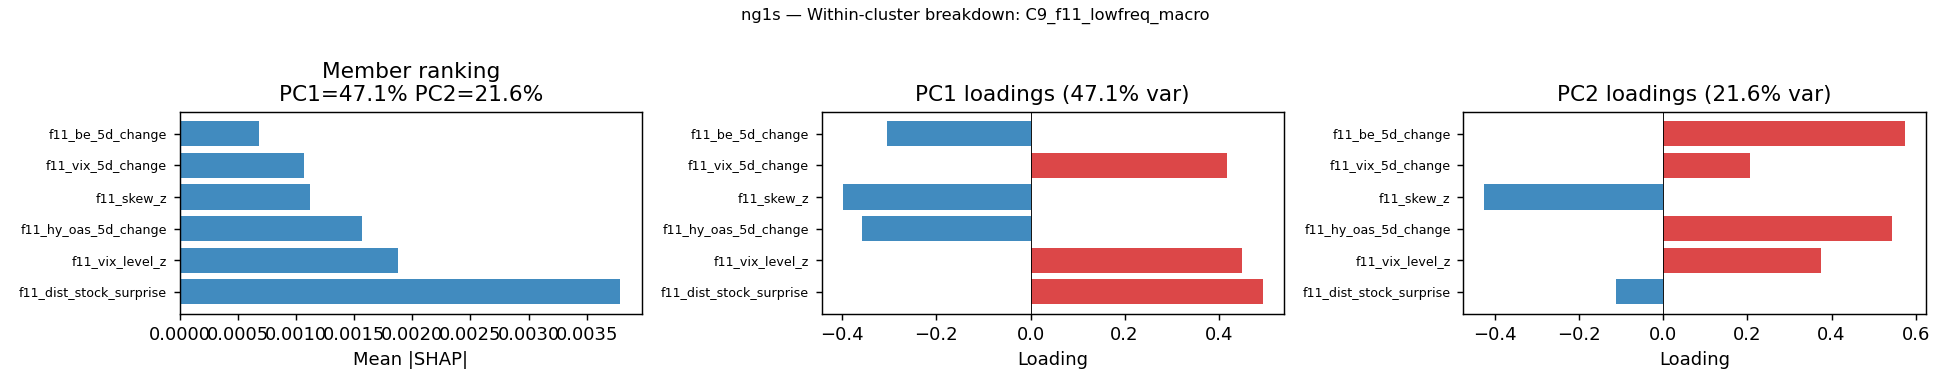

In [23]:
wc = load(BASE / 'ng1s' / 'within_cluster_C9_f11_lowfreq_macro.csv')
if not wc.empty:
    pc1 = wc['pca_pc1_var_explained'].iloc[0]
    pc2v = wc.get('pca_pc2_var_explained', None)
    pc2 = pc2v.iloc[0] if pc2v is not None else float('nan')
    import math
    tier = '>= 65% single latent' if pc1 >= 0.65 else ('>= 40% dominant' if pc1 >= 0.40 else '< 40% multi-dim')
    pc2_str = f' PC2={pc2:.1%}' if not math.isnan(pc2) else ''
    label = f'PC1={pc1:.1%}{pc2_str} ({tier})'
    score_col = 'mean_shap_mag' if 'mean_shap_mag' in wc.columns else wc.columns[2]
    display(
        wc[['feature', score_col, 'pc1_loading']].style
        .format({score_col: '{:.4f}', 'pc1_loading': '{:.3f}'})
        .background_gradient(subset=[score_col], cmap='Blues')
        .set_caption(f'ng1s | C9_f11_lowfreq_macro — |SHAP| ranking + PC1 loadings  ({label})')
    )
show(BASE / 'ng1s' / 'within_cluster_C9_f11_lowfreq_macro.png', width=950)


,feature,mean_shap_mag,pc1_loading
0,f2_ret_skew_60,0.0013,0.588
1,f2_ret_kurt_60,0.0021,-0.584
2,f11_gasoline_stock_surprise,0.0067,0.297
3,f11_china_pmi_level,0.0041,0.475


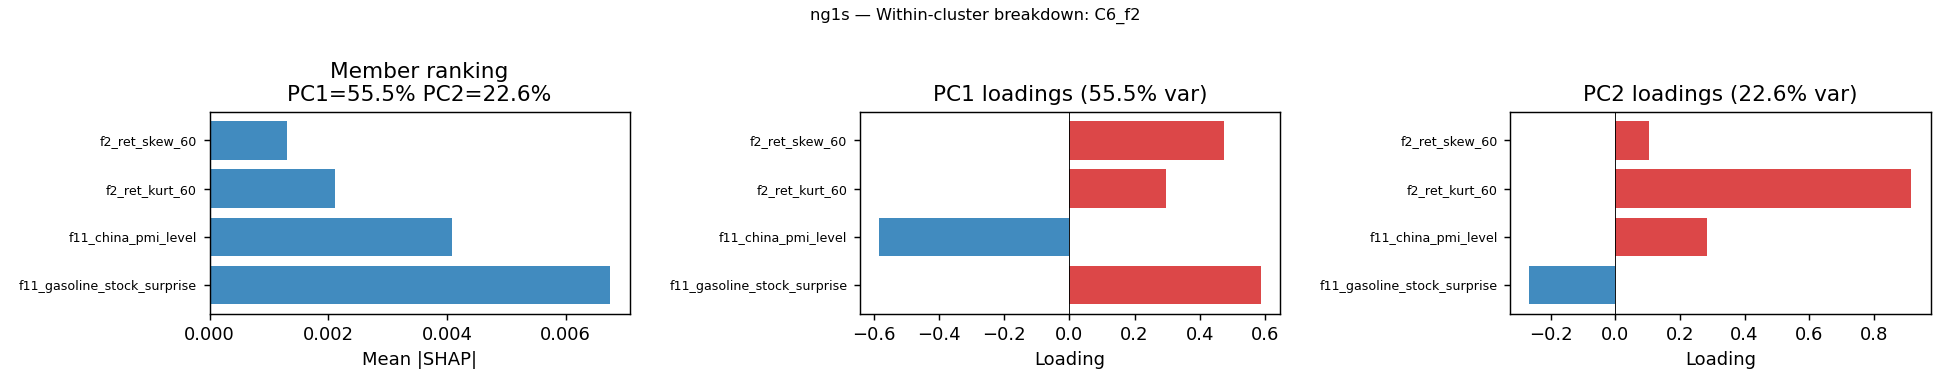

In [24]:
wc = load(BASE / 'ng1s' / 'within_cluster_C6_f2.csv')
if not wc.empty:
    pc1 = wc['pca_pc1_var_explained'].iloc[0]
    pc2v = wc.get('pca_pc2_var_explained', None)
    pc2 = pc2v.iloc[0] if pc2v is not None else float('nan')
    import math
    tier = '>= 65% single latent' if pc1 >= 0.65 else ('>= 40% dominant' if pc1 >= 0.40 else '< 40% multi-dim')
    pc2_str = f' PC2={pc2:.1%}' if not math.isnan(pc2) else ''
    label = f'PC1={pc1:.1%}{pc2_str} ({tier})'
    score_col = 'mean_shap_mag' if 'mean_shap_mag' in wc.columns else wc.columns[2]
    display(
        wc[['feature', score_col, 'pc1_loading']].style
        .format({score_col: '{:.4f}', 'pc1_loading': '{:.3f}'})
        .background_gradient(subset=[score_col], cmap='Blues')
        .set_caption(f'ng1s | C6_f2 — |SHAP| ranking + PC1 loadings  ({label})')
    )
show(BASE / 'ng1s' / 'within_cluster_C6_f2.png', width=950)


### Step 5 · Global per-feature SHAP

Mean |SHAP| per feature. Diagnostic only — below-random mean AUC (0.409).


,feature,shap_magnitude,shap_signed,mdi
0,f5_signal,0.0264,-0.0264,0.0518
1,f11_move_z,0.0168,0.0049,0.0479
2,f7_oi_level,0.0122,0.0122,0.0267
3,f2_vol_60,0.0095,0.0095,0.0235
4,f11_move_vix_ratio,0.0084,0.0054,0.0260
5,f5_long_bias_20,0.0077,-0.0077,0.0208
6,f11_hy_oas_z,0.0070,0.0047,0.0199
7,f11_vix_term_slope,0.0069,0.0052,0.0296
8,f11_baltic_dry_z,0.0068,0.0010,0.0234
9,f11_gasoline_stock_surprise,0.0067,0.0013,0.0320


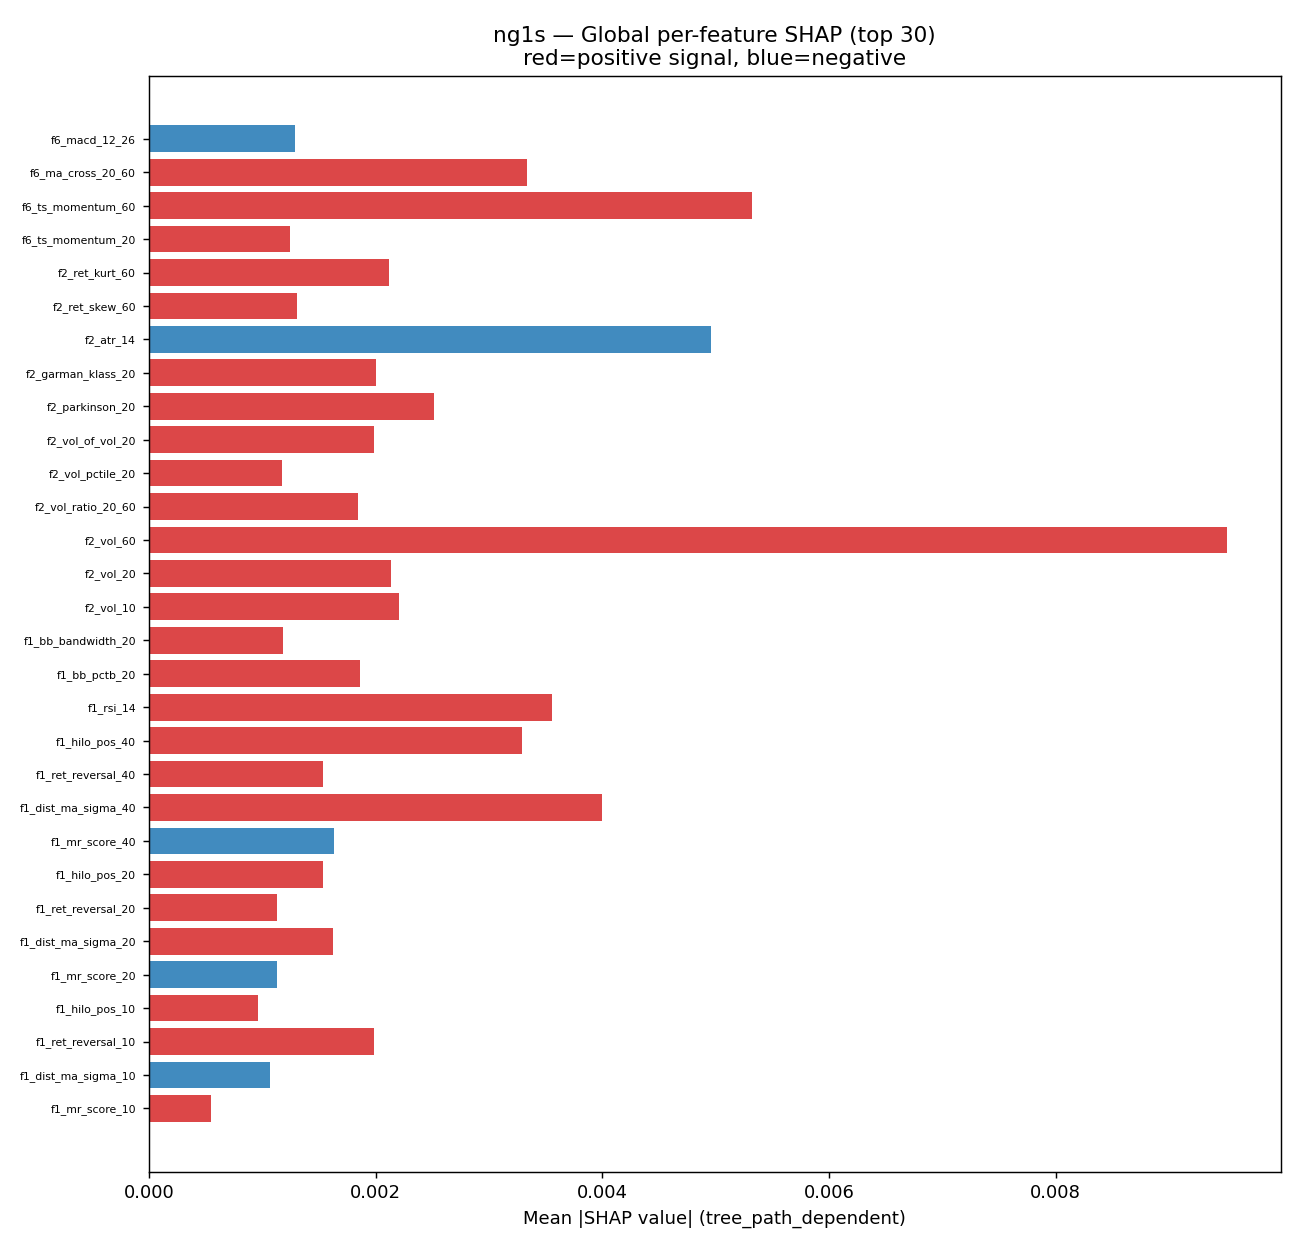

In [25]:
gs = load(BASE / 'ng1s' / 'global_shap_summary.csv')
if not gs.empty:
    display(
        gs.head(25).style
        .format({'shap_magnitude': '{:.4f}', 'shap_signed': '{:.4f}', 'mdi': '{:.4f}'})
        .background_gradient(subset=['shap_magnitude'], cmap='Blues')
        .set_caption('ng1s — top 25 features by mean|SHAP| (NO SIGNAL, below-random AUC)')
    )
show(BASE / 'ng1s' / 'global_shap_chart.png', width=1000)


---
## Cross-instrument findings — energy

Structured summary across cl1s, ho1s, rb1s, ng1s.


In [26]:
ENERGY_INSTS = ['cl1s', 'ho1s', 'rb1s', 'ng1s']
NOSIGNAL = {'ho1s', 'rb1s', 'ng1s'}

rows = []
for inst in ENERGY_INSTS:
    mda  = load(BASE / inst / 'clustered_mda_full.csv')
    ra   = load(BASE / inst / 'rank_agreement.csv')
    meta = load(BASE / inst / 'champion_meta.csv')
    if mda.empty:
        continue
    top = mda.iloc[0]
    sig_count = int(mda['significant'].sum())
    tau_1 = ra['kendall_tau'].iloc[0] if not ra.empty else float('nan')
    champion = meta['model_type'].iloc[0].upper() if not meta.empty else '?'
    signal = meta['signal'].iloc[0] if not meta.empty else False
    rows.append({
        'inst': inst,
        'champion': champion,
        'signal': '\u2713' if signal else '\u2717',
        'n_sig_clusters': sig_count,
        'top_cluster': top['cluster'],
        'top_mda': round(top['mean_drop'], 4),
        'tau_primary': round(tau_1, 2) if not pd.isna(tau_1) else 'n/a',
    })

summary = pd.DataFrame(rows).set_index('inst')
display(summary.style.set_caption('Energy champions — cross-instrument summary'))


,champion,signal,n_sig_clusters,top_cluster,top_mda,tau_primary
inst,,,,,,
cl1s,XGB,✓,1,C14_f11,0.223800,0.330000
ho1s,LOGISTIC,✗,0,F5_signal,0.173500,0.310000
rb1s,LOGISTIC,✗,2,F5_signal,0.092000,0.170000
ng1s,RF,✗,0,C13_f11,0.073500,-0.170000


### Key observations

**CL1S** is the only confirmed signal in energy. It is driven overwhelmingly by a single
cluster of volatility/macro features (C14_f11, MDA 0.224) — roughly 50× the next cluster.
`f11_move_z` and `f2_vol_60` jointly define a volatility-regime latent factor. Crucially,
the internal F5_signal cluster is negative, implying crude oil signal quality features
do not contribute — predictability is entirely externally sourced from cross-asset fear indicators.

**HO1S/RB1S/NG1S** share the `energy_all` pooled model. No robust importance structure
is identifiable: ho1s has enormous fold-to-fold variance (±0.303); rb1s shows two borderline
significant clusters but no OOS signal; ng1s AUC is below random (0.409). The pooled model
learns some internal consistency across energy instruments but cannot produce reliable
ho1s/rb1s/ng1s-specific predictions — consistent with the selection table's lower CI values.

**C13_f11** (containing `f11_move_z`) ranks in the top 3 by raw MDA for *all four* energy
instruments, suggesting it is a common but noisy macro signal for energy markets.
Only for CL1S is it reliably above noise.
